# 05 — Feature Engineering

**Input:** bảng `public.cleaned_city_temperature` (hoặc `data/processed/cleaned_city_temperature.csv`) được bàn giao từ `03_data_cleaning.ipynb`.

**Output:** `data/processed/feature_engineered_data.csv.gz`, `data/processed/feature_metadata.json`, `data/sample/feature_sample.csv` và (tùy chọn) bảng `public.city_temperature_features`.

Notebook này giữ nguyên grain **một thành phố tại một tháng**. Mỗi dòng được định danh bằng khóa nghiệp vụ `observation_date + city_name + country_name + latitude + longitude`; biến mục tiêu là `city_average_temperature`.

## 1. Mục tiêu, vai trò và pipeline Feature Engineering

### 1.1. Mục tiêu của Notebook

Notebook 05 biến tập dữ liệu đã làm sạch thành một tập **đặc trưng (feature)** có căn cứ, không rò rỉ dữ liệu và sẵn sàng cho huấn luyện mô hình. Các công việc chính gồm:

1. Chuyển các quan sát định lượng của Notebook 04 thành ý tưởng đặc trưng cụ thể, mỗi đặc trưng đều có lý do xuất phát từ EDA.
2. Xây dựng bảy nhóm đặc trưng: thời gian, địa lý, tương tác, khí hậu theo vị trí, trễ/trượt, bối cảnh toàn cầu và chất lượng dữ liệu.
3. Đánh giá từng đặc trưng bằng tương quan tuyến tính, tương quan hạng, tỷ lệ phương sai giải thích và feature importance.
4. Kiểm tra và loại bỏ hai rủi ro đã được Notebook 04 chỉ ra: **rò rỉ dữ liệu (leakage)** và **đa cộng tuyến (multicollinearity)**.
5. Lựa chọn đặc trưng bằng bộ quy tắc định lượng công khai, thay vì giữ lại toàn bộ.
6. Lưu tập đặc trưng cùng file metadata ghi rõ danh sách, thứ tự và mốc thời gian train để Notebook 06 tái sử dụng chính xác.

### 1.2. Vai trò của Feature Engineering trong dự án

Notebook 04 cho thấy các biến thô trong bảng sạch **không phản ánh đúng bản chất khí hậu** của dữ liệu:

- `month` và `quarter` chỉ có tương quan tuyến tính `r ≈ 0.10` với nhiệt độ, dù biên độ mùa vụ lên tới **13.04 °C**. Nguyên nhân là quan hệ tháng–nhiệt độ có tính **tuần hoàn**: tháng 12 và tháng 1 liền kề về khí hậu nhưng cách xa nhau về mặt số học.
- `year` và `decade` chỉ có `r ≈ 0.048`, dù xu hướng ấm lên là thật ở mức **+0.0269 °C/năm**. Tín hiệu dài hạn này bị biên độ mùa vụ và biên độ vĩ độ (lớn hơn nhiều) che lấp.
- `latitude` là driver địa lý mạnh nhất (`r = -0.467`) nhưng vì có dấu, nó trộn lẫn hai thông tin khác nhau: khoảng cách tới xích đạo và bán cầu.

Feature Engineering là bước biểu diễn lại các thông tin đó dưới dạng mà mô hình học được: mã hóa tuần hoàn cho mùa vụ, biến trôi thời gian cho xu hướng, khoảng cách tuyệt đối tới xích đạo cho vĩ độ. Đây cũng là bước duy nhất trong pipeline chịu trách nhiệm **chặn rò rỉ dữ liệu** trước khi mô hình được huấn luyện.

### 1.3. Kiến trúc pipeline

```text
cleaned_city_temperature  (5.579.085 dòng × 32 cột)
   ↓ chỉ đọc 16 cột cần dùng, hạ kiểu dữ liệu
Bảng làm việc trong bộ nhớ
   ↓ khóa vị trí + chỉ số tháng liên tục
7 nhóm đặc trưng
   ↓ đánh giá: Pearson · Spearman · η² · importance
Kiểm tra leakage + multicollinearity
   ↓ bộ quy tắc lựa chọn định lượng
Danh sách đặc trưng cuối cùng
   ↓
feature_engineered_data.csv.gz + feature_metadata.json
   ↓
Notebook 06 — Machine Learning
```

Các nguyên tắc thiết kế chính:

- **Chỉ đọc cột cần dùng.** 16 trong 32 cột được nạp; nhóm `land_max/land_min/land_and_ocean` bị bỏ ngay từ bước đọc vì Notebook 04 đã đo được `r > 0.98` giữa chúng.
- **Mọi đặc trưng thống kê chỉ dùng dữ liệu train.** Trung bình khí hậu theo vị trí được tính trên giai đoạn `year <= TRAIN_CUTOFF_YEAR`, không bao giờ trên toàn bộ dữ liệu.
- **Mọi đặc trưng trễ chỉ dùng quá khứ.** Lag được tra cứu theo lịch qua chỉ số tháng liên tục, không dùng `shift()` theo số dòng — vì bảng sạch có khoảng trống tháng.
- **Đặc trưng suy ra từ target không được làm đặc trưng.** Cột lệch chuẩn khí hậu chỉ dùng để phân tích và không được lưu ra file.
- **Quyết định giữ/loại do số liệu quyết định.** Bảng lựa chọn ở Mục 7 được sinh ra từ bộ quy tắc, không gán tay.

## 2. Chuẩn bị môi trường và cấu hình

### 2.1. Nạp các thư viện cần thiết

`pandas` và `numpy` phục vụ xây dựng đặc trưng; `matplotlib` và `seaborn` vẽ biểu đồ đánh giá; `SQLAlchemy` kết hợp `psycopg2` dùng để đọc/ghi PostgreSQL; `python-dotenv` nạp cấu hình từ `.env` mà không ghi mật khẩu vào notebook.

In [2]:
import gc
import json
import os
import shutil
import warnings
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 170)
pd.set_option('display.float_format', lambda value: f'{value:,.4f}')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (13, 5.5)
plt.rcParams['font.size'] = 10
warnings.filterwarnings('ignore', category=FutureWarning)

print(f'pandas {pd.__version__} · numpy {np.__version__}')

pandas 3.0.5 · numpy 2.5.1


Notebook chỉ dùng các thư viện đã có trong `requirements.txt`. `scikit-learn` là **tùy chọn**: nếu môi trường chưa cài, Mục 6.3 sẽ tự chuyển sang phương án đánh giá thuần `pandas`/`numpy` và notebook vẫn chạy hết.

### 2.2. Xác định thư mục dự án và đầu ra

Notebook có thể được mở từ thư mục gốc, `notebooks_v1/` hoặc `notebooks_v2/`. Hàm dưới tìm project root dựa trên hai thư mục ổn định `data/` và `SQL/`, sau đó chuẩn bị các thư mục đầu ra.

In [3]:
def find_project_root(start: Path) -> Path:
    """Tìm thư mục gốc chứa cả data/ và SQL/."""
    for candidate in (start, *start.parents):
        if (candidate / 'data').is_dir() and (candidate / 'SQL').is_dir():
            return candidate
    raise FileNotFoundError('Không tìm thấy project root chứa data/ và SQL/.')


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
SAMPLE_DIR = PROJECT_ROOT / 'data' / 'sample'
REPORT_IMAGES_DIR = PROJECT_ROOT / 'reports' / 'images'
for directory in (PROCESSED_DIR, SAMPLE_DIR, REPORT_IMAGES_DIR):
    directory.mkdir(parents=True, exist_ok=True)

CLEANED_CSV_PATH = PROCESSED_DIR / 'cleaned_city_temperature.csv'
CLEANED_TABLE = 'cleaned_city_temperature'
FEATURE_TABLE = 'city_temperature_features'
METADATA_PATH = PROCESSED_DIR / 'feature_metadata.json'
SAMPLE_PATH = SAMPLE_DIR / 'feature_sample.csv'

print('Project root   :', PROJECT_ROOT)
print('Input CSV      :', CLEANED_CSV_PATH, '| tồn tại:', CLEANED_CSV_PATH.is_file())
print('Processed dir  :', PROCESSED_DIR)
print('Report images  :', REPORT_IMAGES_DIR)

Project root   : E:\project1\Global-Surface-Temperature-Analysis
Input CSV      : E:\project1\Global-Surface-Temperature-Analysis\data\processed\cleaned_city_temperature.csv | tồn tại: True
Processed dir  : E:\project1\Global-Surface-Temperature-Analysis\data\processed
Report images  : E:\project1\Global-Surface-Temperature-Analysis\reports\images


Đường dẫn in ra phải trỏ tới đúng project hiện tại. Notebook không đọc, ghi hoặc thay đổi bất kỳ file nào trong `data/raw/`.

### 2.3. Tham số cấu hình của notebook

Toàn bộ tham số điều khiển được gom vào một cell duy nhất để dễ tinh chỉnh mà không phải đọc lại code phía dưới:

- `FAST_MODE`: bật để chạy thử nhanh trên một phần dữ liệu. Vì Notebook 03 đã ghi CSV theo thứ tự `country_name, city_name, latitude, longitude, observation_date`, việc lấy `FAST_MODE_ROWS` dòng đầu cho ra các chuỗi thời gian **trọn vẹn** của vài trăm thành phố đầu tiên — đủ để kiểm tra đúng logic lag/rolling. Đặt `False` cho lần chạy chính thức.
- `TRAIN_CUTOFF_YEAR`: mốc chia train/test theo thời gian. Mọi đặc trưng thống kê chỉ được tính từ dữ liệu `year <= TRAIN_CUTOFF_YEAR`. **Notebook 06 phải dùng lại đúng mốc này** (đọc từ `feature_metadata.json`), nếu không sẽ phát sinh rò rỉ.
- `EVAL_SAMPLE_ROWS`: số dòng lấy mẫu cho các phép đánh giá đặc trưng. Tương quan trên mẫu 400.000 dòng đã đủ ổn định và nhanh hơn nhiều so với chạy trên 5,58 triệu dòng.
- `OUTPUT_COMPRESSION`: `'gzip'` cho ra file khoảng 200–300 MB; `None` cho ra file `.csv` thô khoảng 1,3 GB. Mục 9.2 sẽ kiểm tra dung lượng đĩa trống trước khi ghi.

In [4]:
# --- Chế độ chạy ---------------------------------------------------------
FAST_MODE = False          # True: chạy thử nhanh trên một phần dữ liệu
FAST_MODE_ROWS = 400_000   # số dòng đầu được đọc khi FAST_MODE = True

# --- Mốc thời gian train (chống rò rỉ cho đặc trưng thống kê) ------------
TRAIN_CUTOFF_YEAR = 1993   # train: 1863–1993 · test: 1994–2013

# --- Đánh giá đặc trưng --------------------------------------------------
EVAL_SAMPLE_ROWS = 400_000
ETA_SQUARED_BINS = 20
RANDOM_SEED = 42

# --- Quy tắc lựa chọn đặc trưng (Mục 7) ---------------------------------
MIN_ETA_SQUARED = 0.005    # dưới ngưỡng này coi như không giải thích được target
MIN_ABS_PEARSON = 0.05
REDUNDANCY_THRESHOLD = 0.95

# --- Đầu ra --------------------------------------------------------------
OUTPUT_COMPRESSION = 'gzip'   # 'gzip' hoặc None
SAMPLE_ROWS = 50_000
TARGET_COLUMN = 'city_average_temperature'

rng = np.random.default_rng(RANDOM_SEED)

OUTPUT_PATH = PROCESSED_DIR / (
    'feature_engineered_data.csv.gz' if OUTPUT_COMPRESSION == 'gzip'
    else 'feature_engineered_data.csv'
)

print(f'FAST_MODE          : {FAST_MODE}')
print(f'TRAIN_CUTOFF_YEAR  : {TRAIN_CUTOFF_YEAR}')
print(f'EVAL_SAMPLE_ROWS   : {EVAL_SAMPLE_ROWS:,}')
print(f'Target             : {TARGET_COLUMN}')
print(f'Output             : {OUTPUT_PATH.name}')

FAST_MODE          : False
TRAIN_CUTOFF_YEAR  : 1993
EVAL_SAMPLE_ROWS   : 400,000
Target             : city_average_temperature
Output             : feature_engineered_data.csv.gz


Nếu `FAST_MODE = True`, mọi số liệu in ra sau đó chỉ mang tính kiểm tra logic và **không được dùng cho báo cáo**. Kết quả chính thức phải chạy với `FAST_MODE = False`.

### 2.4. Đọc cấu hình PostgreSQL (tùy chọn)

Notebook ưu tiên đọc dữ liệu từ PostgreSQL để dùng đúng nguồn đã được Notebook 03 kiểm định. Nếu không có `.env`, không cài driver, hoặc server không phản hồi, notebook **tự động chuyển sang đọc file CSV** trong `data/processed/` và in rõ nguồn đang dùng — nhờ vậy notebook vẫn chạy được từ trên xuống trên máy chưa dựng database.

Tạo file `.env` ở project root từ `.env.example`:

```text
DB_HOST=localhost
DB_PORT=5432
DB_NAME=climate_db
DB_USER=postgres
DB_PASSWORD=<mật khẩu PostgreSQL trên máy đang chạy>
```

In [5]:
DB_ENGINE = None
DB_AVAILABLE = False
DB_STATUS = 'Chưa kiểm tra'

ENV_PATH = PROJECT_ROOT / '.env'
if not ENV_PATH.is_file():
    DB_STATUS = 'Không tìm thấy .env — sẽ đọc dữ liệu từ CSV.'
else:
    try:
        from dotenv import load_dotenv
        from sqlalchemy import URL, create_engine, text

        load_dotenv(ENV_PATH, override=False)
        required_env = ('DB_HOST', 'DB_PORT', 'DB_NAME', 'DB_USER', 'DB_PASSWORD')
        missing_env = [name for name in required_env if not os.getenv(name)]
        if missing_env:
            DB_STATUS = f'.env thiếu các biến {missing_env} — sẽ đọc dữ liệu từ CSV.'
        else:
            DB_ENGINE = create_engine(
                URL.create(
                    drivername='postgresql+psycopg2',
                    username=os.environ['DB_USER'],
                    password=os.environ['DB_PASSWORD'],
                    host=os.environ['DB_HOST'],
                    port=int(os.environ['DB_PORT']),
                    database=os.environ['DB_NAME'],
                ),
                pool_pre_ping=True,
                connect_args={'connect_timeout': 10},
            )
            # Chỉ đọc: xác nhận database và sự tồn tại của bảng nguồn.
            check_sql = text(
                'SELECT current_database() AS database_name, '
                f"to_regclass('public.{CLEANED_TABLE}') IS NOT NULL AS source_table_exists"
            )
            with DB_ENGINE.connect() as connection:
                db_check = pd.read_sql_query(check_sql, connection)
            display(db_check)
            if bool(db_check.loc[0, 'source_table_exists']):
                DB_AVAILABLE = True
                DB_STATUS = f"Đã kết nối {db_check.loc[0, 'database_name']}.public.{CLEANED_TABLE}"
            else:
                DB_STATUS = f'Không tìm thấy public.{CLEANED_TABLE} — sẽ đọc dữ liệu từ CSV.'
    except Exception as error:                     # noqa: BLE001 - gom mọi lỗi hạ tầng
        DB_STATUS = f'PostgreSQL không khả dụng ({type(error).__name__}) — sẽ đọc dữ liệu từ CSV.'
        DB_ENGINE = None

print('PostgreSQL:', DB_STATUS)

,database_name,source_table_exists
0,climate_db,True


PostgreSQL: Đã kết nối climate_db.public.cleaned_city_temperature


Cell này chỉ thực hiện truy vấn chỉ đọc và không hiển thị mật khẩu. `DB_AVAILABLE = True` nghĩa là dữ liệu sẽ được đọc trực tiếp từ bảng sạch trong `climate_db`; `False` nghĩa là notebook dùng file CSV tương đương do chính Notebook 03 xuất ra. Hai nguồn có cùng data contract nên kết quả đặc trưng không đổi.

## 3. Đọc dữ liệu đã làm sạch

### 3.1. Xác nhận data contract từ Notebook 03

Theo Notebook 03, bảng sạch phải có **5.579.085 dòng**, **32 cột**, **50 quốc gia**, thời gian từ `1863-01-01` đến `2013-09-01` và không còn dòng nào thiếu biến mục tiêu. Các hằng số dưới đây được dùng để đối chiếu sau khi nạp dữ liệu.

In [6]:
EXPECTED_CLEAN_ROWS = 5_579_085
EXPECTED_COUNTRIES = 50
EXPECTED_MIN_DATE = pd.Timestamp('1863-01-01')
EXPECTED_MAX_DATE = pd.Timestamp('2013-09-01')

BUSINESS_KEY_COLUMNS = [
    'observation_date', 'city_name', 'country_name', 'latitude', 'longitude',
]
LOCATION_KEY_COLUMNS = ['city_name', 'country_name', 'latitude', 'longitude']

print(f'Kỳ vọng {EXPECTED_CLEAN_ROWS:,} dòng · {EXPECTED_COUNTRIES} quốc gia · '
      f'{EXPECTED_MIN_DATE.date()} → {EXPECTED_MAX_DATE.date()}')

Kỳ vọng 5,579,085 dòng · 50 quốc gia · 1863-01-01 → 2013-09-01


### 3.2. Chọn cột cần dùng và kiểu dữ liệu tối ưu

Bảng sạch có 32 cột nhưng Notebook 05 chỉ cần **16 cột**. Việc bỏ 16 cột còn lại ngay từ bước đọc là tối ưu quan trọng nhất của notebook này: giảm khoảng một nửa thời gian đọc và bộ nhớ.

Cụ thể, ba cột `land_max_temperature`, `land_min_temperature` và `land_and_ocean_average_temperature` **không được đọc** vì Notebook 04 đã đo được `r > 0.98` giữa chúng và `land_average_temperature`; giữ cả nhóm chỉ tạo đa cộng tuyến mà không thêm thông tin. Các cột `*_uncertainty` của country/global và các cờ `*_available`, `*_matched` cũng không cần cho việc xây dựng đặc trưng.

Hai cột được đọc **có chủ đích để chứng minh rủi ro** ở Mục 6.5 rồi loại bỏ:

- `major_city_average_temperature` — Notebook 04 đo `r = 1.000` với target, đây là rò rỉ.
- `country_average_temperature` — trung bình cùng tháng của quốc gia, đã bao gồm chính thành phố đang dự báo.

In [7]:
CALENDAR_COLUMNS = ['year', 'month', 'quarter', 'decade']
TEMPERATURE_COLUMNS = [
    TARGET_COLUMN,                              # biến mục tiêu
    'city_average_temperature_uncertainty',     # đặc trưng chất lượng dữ liệu
    'land_average_temperature',                 # bối cảnh toàn cầu (giữ 1 trong nhóm land_*)
    'country_average_temperature',              # đọc để chứng minh rủi ro ở Mục 6.5
    'major_city_average_temperature',           # đọc để chứng minh rò rỉ ở Mục 6.5
]
FLAG_COLUMNS = ['is_major_city', 'city_temperature_iqr_outlier']

USED_COLUMNS = BUSINESS_KEY_COLUMNS + CALENDAR_COLUMNS + TEMPERATURE_COLUMNS + FLAG_COLUMNS

# Kiểu dữ liệu nhỏ nhất còn biểu diễn đúng giá trị (xem CHECK constraint của Notebook 03).
READ_DTYPES = {
    'year': 'int16', 'month': 'int8', 'quarter': 'int8', 'decade': 'int16',
    'city_name': 'category', 'country_name': 'category',
    'latitude': 'float32', 'longitude': 'float32',
    **{column: 'float32' for column in TEMPERATURE_COLUMNS},
}

print(f'Đọc {len(USED_COLUMNS)}/32 cột:')
for index, column in enumerate(USED_COLUMNS, start=1):
    print(f'  {index:2d}. {column}')

Đọc 16/32 cột:
   1. observation_date
   2. city_name
   3. country_name
   4. latitude
   5. longitude
   6. year
   7. month
   8. quarter
   9. decade
  10. city_average_temperature
  11. city_average_temperature_uncertainty
  12. land_average_temperature
  13. country_average_temperature
  14. major_city_average_temperature
  15. is_major_city
  16. city_temperature_iqr_outlier


`city_name` và `country_name` dùng `category` vì chỉ có 3.070 và 50 giá trị duy nhất trên hơn 5,5 triệu dòng — hạ từ chuỗi Python xuống mã số nguyên tiết kiệm phần lớn bộ nhớ của hai cột này. Các cột nhiệt độ dùng `float32` thay vì `float64`: dữ liệu gốc chỉ có 3 chữ số thập phân nên không mất thông tin, mà giảm một nửa bộ nhớ.

### 3.3. Nạp dữ liệu theo từng chunk

Dữ liệu được nhận theo các chunk 500.000 dòng để giảm bộ nhớ đỉnh trong lúc truyền, sau đó ghép thành một DataFrame duy nhất — cùng cách làm với Notebook 03. Hai nhánh PostgreSQL và CSV dùng chung hàm chuẩn hóa `compact_chunk` nên kết quả giống nhau bất kể nguồn.

In [8]:
CHUNK_SIZE = 500_000


def compact_chunk(chunk: pd.DataFrame) -> pd.DataFrame:
    """Chuẩn hóa kiểu dữ liệu của một chunk trước khi ghép DataFrame lớn."""
    chunk['observation_date'] = pd.to_datetime(chunk['observation_date'], errors='coerce')
    for column, dtype in READ_DTYPES.items():
        if column in chunk.columns and chunk[column].dtype.name != dtype:
            chunk[column] = chunk[column].astype(dtype)
    for column in FLAG_COLUMNS:
        # CSV ghi 'True'/'False'; PostgreSQL trả về bool. Xử lý được cả hai.
        if chunk[column].dtype != bool:
            chunk[column] = (
                chunk[column].map({'True': True, 'False': False, True: True, False: False})
                .astype('bool')
            )
    return chunk


def load_from_postgres() -> pd.DataFrame:
    """Đọc bảng sạch từ PostgreSQL theo từng chunk."""
    from sqlalchemy import text

    limit_clause = f' LIMIT {FAST_MODE_ROWS}' if FAST_MODE else ''
    query = text(
        f"SELECT {', '.join(USED_COLUMNS)} FROM public.{CLEANED_TABLE} "
        'ORDER BY country_name, city_name, latitude, longitude, observation_date'
        f'{limit_clause}'
    )
    parts = []
    with DB_ENGINE.connect() as connection:
        for chunk in pd.read_sql_query(query, connection, chunksize=CHUNK_SIZE):
            parts.append(compact_chunk(chunk))
    return pd.concat(parts, ignore_index=True)


def load_from_csv() -> pd.DataFrame:
    """Đọc file CSV sạch theo từng chunk, chỉ lấy các cột cần dùng."""
    if not CLEANED_CSV_PATH.is_file():
        raise FileNotFoundError(
            f'Không tìm thấy {CLEANED_CSV_PATH}. Hãy chạy Notebook 03 trước.'
        )
    reader = pd.read_csv(
        CLEANED_CSV_PATH,
        usecols=USED_COLUMNS,
        nrows=FAST_MODE_ROWS if FAST_MODE else None,
        chunksize=CHUNK_SIZE,
        encoding='utf-8',
    )
    parts = [compact_chunk(chunk) for chunk in reader]
    return pd.concat(parts, ignore_index=True)


if DB_AVAILABLE:
    DATA_SOURCE = f'POSTGRESQL · public.{CLEANED_TABLE}'
    feature_df = load_from_postgres()
else:
    DATA_SOURCE = f'CSV · {CLEANED_CSV_PATH.name}'
    feature_df = load_from_csv()

# Bảo đảm đúng thứ tự cột bất kể nguồn dữ liệu.
feature_df = feature_df[USED_COLUMNS]

print(f'Nguồn dữ liệu : {DATA_SOURCE}')
print(f'Đã nạp        : {len(feature_df):,} dòng × {feature_df.shape[1]} cột')

Nguồn dữ liệu : POSTGRESQL · public.cleaned_city_temperature
Đã nạp        : 5,579,085 dòng × 16 cột


Dòng `Nguồn dữ liệu` cho biết notebook đang đọc từ PostgreSQL hay từ CSV. Cell chỉ đọc và chưa tạo đặc trưng nào; số cột phải đúng bằng 16.

### 3.4. Kiểm tra data contract, grain và bộ nhớ

Trước khi xây dựng đặc trưng, notebook kiểm tra ba điều kiện. Hai điều kiện đầu là **lỗi cấu trúc** và sẽ làm dừng notebook, vì mọi đặc trưng trễ phía sau đều dựa vào giả định grain duy nhất:

1. Khóa nghiệp vụ City–month phải duy nhất.
2. Biến mục tiêu không được có giá trị thiếu.

Điều kiện thứ ba — row count, số quốc gia, khoảng thời gian — chỉ **cảnh báo**, vì `FAST_MODE` cố tình đọc ít dòng hơn và người dùng có thể chạy lại pipeline với phạm vi khác.

In [9]:
duplicate_key_rows = int(feature_df.duplicated(subset=BUSINESS_KEY_COLUMNS).sum())
missing_target_rows = int(feature_df[TARGET_COLUMN].isna().sum())
if duplicate_key_rows:
    raise RuntimeError(
        f'Có {duplicate_key_rows:,} dòng trùng khóa nghiệp vụ City–month. '
        'Đặc trưng trễ yêu cầu grain duy nhất; hãy kiểm tra lại Notebook 03.'
    )
if missing_target_rows:
    raise RuntimeError(
        f'Có {missing_target_rows:,} dòng thiếu {TARGET_COLUMN}. '
        'Notebook 03 phải loại các dòng này trước khi bàn giao.'
    )

actual_countries = int(feature_df['country_name'].nunique())
actual_locations = int(feature_df.groupby(LOCATION_KEY_COLUMNS, observed=True).ngroups)
contract_report = pd.DataFrame(
    {
        'Expected': [EXPECTED_CLEAN_ROWS, EXPECTED_COUNTRIES,
                     EXPECTED_MIN_DATE.date(), EXPECTED_MAX_DATE.date()],
        'Actual': [len(feature_df), actual_countries,
                   feature_df['observation_date'].min().date(),
                   feature_df['observation_date'].max().date()],
    },
    index=['Row count', 'Country count', 'Min observation date', 'Max observation date'],
)
contract_report['Match'] = contract_report['Expected'].astype(str) == contract_report['Actual'].astype(str)
display(contract_report)

print(f'Số vị trí (city+country+toạ độ): {actual_locations:,}')
print(f'Bộ nhớ đang dùng               : '
      f'{feature_df.memory_usage(deep=True).sum() / 1024 ** 2:,.1f} MB')
print(f'Khóa nghiệp vụ duy nhất        : PASS ({duplicate_key_rows} dòng trùng)')
print(f'Biến mục tiêu đầy đủ           : PASS ({missing_target_rows} dòng thiếu)')

if not contract_report['Match'].all():
    if FAST_MODE:
        print('\nLƯU Ý: FAST_MODE đang bật nên row count nhỏ hơn contract là bình thường.')
    else:
        print('\nCẢNH BÁO: dữ liệu không khớp contract của Notebook 03. '
              'Hãy kiểm tra lại phiên bản bảng sạch trước khi dùng kết quả cho báo cáo.')

,Expected,Actual,Match
Row count,5579085,5579085,True
Country count,50,50,True
Min observation date,1863-01-01,1863-01-01,True
Max observation date,2013-09-01,2013-09-01,True


Số vị trí (city+country+toạ độ): 3,119
Bộ nhớ đang dùng               : 400.5 MB
Khóa nghiệp vụ duy nhất        : PASS (0 dòng trùng)
Biến mục tiêu đầy đủ           : PASS (0 dòng thiếu)


Hai dòng `PASS` xác nhận grain City–month duy nhất và biến mục tiêu đầy đủ — đây là điều kiện bắt buộc để các đặc trưng trễ ở Mục 5.6 tra cứu đúng theo lịch. Bộ nhớ in ra nên ở mức vài trăm MB nhờ các kiểu dữ liệu đã hạ ở Mục 3.2; nếu con số này lên tới nhiều GB, rất có thể `READ_DTYPES` chưa được áp dụng.

In [10]:
display(feature_df.head())
display(feature_df.dtypes.to_frame('dtype'))

,observation_date,city_name,country_name,latitude,longitude,year,month,quarter,decade,city_average_temperature,city_average_temperature_uncertainty,land_average_temperature,country_average_temperature,major_city_average_temperature,is_major_city,city_temperature_iqr_outlier
0,1863-01-01,Bahia Blanca,Argentina,-39.3800,-62.4300,1863,1,1,1860,20.3650,2.9650,3.0340,20.2260,NaN,False,False
1,1863-02-01,Bahia Blanca,Argentina,-39.3800,-62.4300,1863,2,1,1860,20.3580,3.0540,3.2530,19.5130,NaN,False,False
2,1863-03-01,Bahia Blanca,Argentina,-39.3800,-62.4300,1863,3,1,1860,16.6370,1.6250,4.6820,16.4700,NaN,False,False
3,1863-04-01,Bahia Blanca,Argentina,-39.3800,-62.4300,1863,4,2,1860,13.9310,1.6410,7.9310,13.5310,NaN,False,False
4,1863-05-01,Bahia Blanca,Argentina,-39.3800,-62.4300,1863,5,2,1860,9.1430,1.6530,11.0810,9.0090,NaN,False,False


,dtype
observation_date,datetime64[s]
city_name,str
country_name,str
latitude,float32
longitude,float32
year,int16
month,int8
quarter,int8
decade,int16
city_average_temperature,float32


Bảng mẫu cho thấy dữ liệu đã ở đúng grain City–month với các cột nghiệp vụ trực tiếp. Cột `major_city_average_temperature` phần lớn là `NaN` — đúng như Notebook 04 mô tả: chỉ khoảng 2,7% dòng thuộc nhóm Major City.

## 4. Ý tưởng xây dựng Feature từ kết quả EDA

### 4.1. Bảng chuyển quan sát EDA thành ý tưởng Feature

Mỗi nhóm đặc trưng dưới đây bắt nguồn từ một quan sát định lượng cụ thể trong Notebook 04, không phải từ danh sách đặc trưng chung chung.

| # | Quan sát từ Notebook 04 | Số liệu | Ý tưởng Feature | Nhóm |
|---|---|---|---|---|
| 1 | Biên độ mùa vụ rất lớn nhưng tương quan tuyến tính của `month` lại yếu, vì quan hệ tháng–nhiệt độ có tính tuần hoàn | biên độ 13.04 °C, `r ≈ 0.10` | Mã hóa tuần hoàn `sin`/`cos` của tháng thay cho số nguyên thô | Thời gian |
| 2 | Mùa vụ ở Nam bán cầu **ngược pha** với Bắc bán cầu; dữ liệu có vĩ độ từ −52.24 đến 69.92 | 50 quốc gia, cả hai bán cầu | Dịch tháng 6 kỳ cho Nam bán cầu rồi mới mã hóa tuần hoàn | Thời gian |
| 3 | Xu hướng ấm lên là thật nhưng nhỏ và dài hạn, bị mùa vụ che lấp | +0.0269 °C/năm, `r ≈ 0.048` | Biến trôi thời gian `years_since_start` | Thời gian |
| 4 | `latitude` là driver địa lý mạnh nhất nhưng có dấu nên trộn lẫn hai thông tin | `r = -0.467` | Tách thành `abs_latitude` (khoảng cách tới xích đạo) và `hemisphere_north` | Địa lý |
| 5 | Độ lệch chuẩn theo tháng không đều: mùa đông phân tán mạnh hơn mùa hè vì thành phố vĩ độ cao dao động lớn hơn | std đông 11.9–12.9 °C vs hè 5.2–6.1 °C | Tương tác giữa vĩ độ và pha mùa vụ | Tương tác |
| 6 | `city_name` không phải khóa định danh duy nhất, có tên trùng giữa nhiều vị trí | 3.070 tên / 3.119 vị trí | Khóa vị trí ghép `city+country+lat+lon`, rồi tính trung bình khí hậu theo vị trí | Khí hậu theo vị trí |
| 7 | Dữ liệu là chuỗi thời gian theo từng thành phố | grain City–month | Lag 1 tháng, lag 12 tháng, trung bình/độ lệch trượt 12 tháng | Trễ / Trượt |
| 8 | Nhóm `land_*` trùng lặp thông tin nặng | `r > 0.98` lẫn nhau | Chỉ giữ `land_average_temperature`, thêm dạng lệch chuẩn so với trung bình dài hạn | Bối cảnh toàn cầu |
| 9 | Độ bất định giảm dần theo thời gian, phản ánh chất lượng đo lường hơn là nhiệt độ | `r` với year/decade: −0.60 → −0.88; với target ≈ −0.09 | Dùng `city_average_temperature_uncertainty` như tín hiệu chất lượng dữ liệu | Chất lượng dữ liệu |
| 10 | `major_city_average_temperature` trùng khớp hoàn toàn với target khi có mặt | `r = 1.000`, chỉ 2,7% dòng | **Không dùng** — chứng minh rồi loại ở Mục 6.5 | Bị loại |

Lưu ý: đây chỉ là **ý tưởng**. Mục 6 sẽ đo lường và Mục 7 mới quyết định giữ hay loại từng đặc trưng.

### 4.2. Nguyên tắc chống rò rỉ dữ liệu

Rò rỉ dữ liệu (leakage) là việc đưa vào đặc trưng thông tin mà mô hình sẽ **không có** tại thời điểm dự báo, khiến chỉ số đánh giá đẹp giả tạo. Notebook này áp dụng bốn nguyên tắc:

1. **Không dùng phép đo cùng kỳ của chính biến mục tiêu.** `major_city_average_temperature` và `country_average_temperature` đều là giá trị nhiệt độ của cùng tháng đó và đã chứa thông tin của chính thành phố đang dự báo. Cả hai bị loại.
2. **Đặc trưng thống kê chỉ tính trên giai đoạn train.** Trung bình khí hậu theo vị trí được tính từ `year <= TRAIN_CUTOFF_YEAR`. Nếu tính trên toàn bộ dữ liệu, giá trị của giai đoạn test sẽ tham gia vào chính đặc trưng dùng để dự báo giai đoạn test.
3. **Đặc trưng trễ chỉ được nhìn về quá khứ.** Lag được tra cứu tại `month_index - k` theo lịch, không bao giờ tại `+k`.
4. **Đặc trưng suy ra từ target không được làm đặc trưng.** Cột `temp_anomaly_vs_climatology = target − trung bình khí hậu` chứa trực tiếp target, nên chỉ dùng để phân tích ở Mục 8 và **không được lưu ra file** đầu ra.

Mục 6.5 kiểm tra lại các nguyên tắc này bằng phép thử tự động thay vì chỉ dựa vào cam kết.

### 4.3. Khai báo giai đoạn train và sổ đăng ký đặc trưng

`train_period_mask` xác định các dòng được phép tham gia tính đặc trưng thống kê. Hàm `add_feature` là điểm duy nhất ghi đặc trưng vào DataFrame: nó vừa hạ kiểu dữ liệu về `float32`/`int8` để tiết kiệm bộ nhớ, vừa ghi lại metadata của đặc trưng. Nhờ vậy danh sách đặc trưng và mô tả của chúng luôn khớp với code, không phải bảo trì thủ công ở hai nơi.

Trường `availability` ghi điều kiện để đặc trưng dùng được khi dự báo thật:

- `static` — suy ra được chỉ từ thành phố và ngày cần dự báo.
- `train_stat` — cần bảng thống kê khí hậu đã tính từ giai đoạn train (được lưu kèm mô hình).
- `history` — cần chuỗi nhiệt độ quá khứ của chính thành phố đó.
- `same_month_context` — cần chỉ số toàn cầu của tháng đang dự báo.

In [11]:
train_period_mask = feature_df['year'] <= TRAIN_CUTOFF_YEAR
train_row_share = float(train_period_mask.mean())

FEATURE_CATALOG: dict[str, dict] = {}


def add_feature(
    name: str,
    values,
    group: str,
    description: str,
    availability: str = 'static',
    force_keep: bool = False,
    keep_reason: str = '',
) -> None:
    """Ghi một đặc trưng vào feature_df và đăng ký metadata của nó.

    Kiểu dữ liệu được hạ về float32/int8 tại đúng một chỗ để tránh việc
    DataFrame phình lên float64 sau mỗi phép tính numpy.
    """
    series = pd.Series(np.asarray(values), index=feature_df.index)
    if series.dtype == bool:
        series = series.astype('int8')
    elif series.dtype.kind == 'f':
        series = series.astype('float32')
    elif series.dtype.kind in 'iu':
        series = series.astype('int32' if series.abs().max() > 32_000 else 'int16')
    feature_df[name] = series
    FEATURE_CATALOG[name] = {
        'group': group,
        'description': description,
        'availability': availability,
        'force_keep': force_keep,
        'keep_reason': keep_reason,
        'dtype': str(series.dtype),
    }


print(f'Giai đoạn train : year <= {TRAIN_CUTOFF_YEAR}')
print(f'Số dòng train   : {int(train_period_mask.sum()):,} '
      f'({train_row_share:.1%} tổng số dòng)')
print(f'Số dòng test    : {int((~train_period_mask).sum()):,} '
      f'({1 - train_row_share:.1%})')

Giai đoạn train : year <= 1993
Số dòng train   : 4,842,607 (86.8% tổng số dòng)
Số dòng test    : 736,478 (13.2%)


Tỷ lệ dòng train in ra thường cao hơn tỷ lệ số năm, vì Notebook 04 đã chỉ ra độ phủ dữ liệu tăng dần theo thời gian (năm 1863 chỉ có 28.650 dòng). Nếu tỷ lệ test quá nhỏ so với nhu cầu đánh giá, hãy hạ `TRAIN_CUTOFF_YEAR` ở Mục 2.3 và chạy lại từ đây.

## 5. Xây dựng Feature

### 5.1. Khóa vị trí và chỉ số tháng liên tục

Hai khóa kỹ thuật này là nền tảng cho toàn bộ các nhóm đặc trưng phía sau:

- `location_id` — mã số nguyên của một vị trí, ghép từ `city_name + country_name + latitude + longitude`. Notebook 04 đã chỉ ra `city_name` một mình không định danh duy nhất (Springfield, Worcester xuất hiện ở nhiều nơi), nên nếu nhóm theo tên thành phố sẽ trộn lẫn các thành phố khác nhau.
- `month_index` — số tháng liên tục kể từ năm 0, tính bằng `year * 12 + month`. Bảng sạch **có khoảng trống tháng** (Notebook 03 đã loại 58.727 dòng thiếu target), nên `shift(12)` theo số dòng sẽ lấy sai mốc thời gian. Tra cứu theo `month_index - 12` luôn cho đúng cùng tháng năm trước.

Hai khóa được ghép thành một khóa `int64` duy nhất: `location_key = location_id * 30000 + month_index`. Tra cứu trên một chỉ mục `int64` nhanh và nhẹ hơn nhiều so với `MultiIndex` hai tầng trên 5,58 triệu dòng.

In [12]:
feature_df = feature_df.sort_values(
    LOCATION_KEY_COLUMNS + ['observation_date'], kind='mergesort', ignore_index=True
)

feature_df['location_id'] = (
    feature_df.groupby(LOCATION_KEY_COLUMNS, observed=True, sort=False)
    .ngroup()
    .astype('int32')
)
feature_df['month_index'] = (
    feature_df['year'].astype('int32') * 12 + feature_df['month'].astype('int32')
)

# Điều kiện để phép cộng dồn khóa không bị tràn sang bậc location_id.
MONTH_INDEX_SCALE = 30_000
if feature_df['month_index'].max() >= MONTH_INDEX_SCALE:
    raise RuntimeError('month_index vượt quá MONTH_INDEX_SCALE; hãy tăng hằng số này.')
if feature_df['month_index'].min() < 12:
    raise RuntimeError('month_index quá nhỏ để tra cứu lag 12 tháng.')

feature_df['location_key'] = (
    feature_df['location_id'].astype('int64') * MONTH_INDEX_SCALE
    + feature_df['month_index'].astype('int64')
)
if not feature_df['location_key'].is_unique:
    raise RuntimeError('location_key không duy nhất; đặc trưng trễ sẽ tra cứu sai.')

if FAST_MODE:
    # Vị trí cuối cùng có thể bị cắt giữa chuỗi thời gian do nrows; loại để không méo lag.
    last_location = feature_df['location_id'].iloc[-1]
    if feature_df['location_id'].nunique() > 1:
        feature_df = feature_df[feature_df['location_id'] != last_location].reset_index(drop=True)

n_locations = int(feature_df['location_id'].nunique())
print(f'Số vị trí               : {n_locations:,}')
print(f'Số dòng                 : {len(feature_df):,}')
print(f'Số tháng trung bình/vị trí: {len(feature_df) / n_locations:,.0f}')
print(f'location_key duy nhất   : PASS')

Số vị trí               : 3,119
Số dòng                 : 5,579,085
Số tháng trung bình/vị trí: 1,789
location_key duy nhất   : PASS


`location_key duy nhất : PASS` là điều kiện tiên quyết cho Mục 5.6: nó bảo đảm mỗi cặp (vị trí, tháng) chỉ có một giá trị nhiệt độ, nên phép tra cứu lag trả về đúng một kết quả. Số tháng trung bình trên mỗi vị trí cho biết chuỗi thời gian đủ dài để tính trung bình trượt 12 tháng hay không.

### 5.2. Nhóm 1 — Đặc trưng thời gian

Nhóm này giải quyết ba hạn chế của các cột lịch thô.

**Mã hóa tuần hoàn.** Thay `month` bằng cặp `sin`/`cos` trên chu kỳ 12 tháng, để tháng 12 và tháng 1 nằm cạnh nhau trong không gian đặc trưng. Cặp này phải luôn được giữ cùng nhau — một mình `sin` không phân biệt được tháng 3 với tháng 9 — nên cả hai được đánh dấu `force_keep=True`.

**Hiệu chỉnh bán cầu.** Ở Nam bán cầu tháng 1 là giữa hè còn tháng 7 là giữa đông, ngược pha hoàn toàn với Bắc bán cầu. Dữ liệu có vĩ độ từ −52.24 đến 69.92 nên nếu dùng chung một phép mã hóa cho cả hai bán cầu, tín hiệu mùa vụ của hai nhóm sẽ triệt tiêu nhau. `climatic_month` dịch 6 tháng cho các vị trí Nam bán cầu để đưa cả hai về cùng một pha khí hậu.

**Biến trôi thời gian.** `years_since_start` đếm số năm kể từ mốc đầu dữ liệu, cho mô hình một trục tuyến tính để hấp thụ xu hướng +0.0269 °C/năm.

In [13]:
month_values = feature_df['month'].to_numpy(dtype='float32')
is_north = (feature_df['latitude'] >= 0).to_numpy()

# Nam bán cầu lệch pha 6 tháng: tháng 1 (giữa hè) ↔ tháng 7 khí hậu.
climatic_month = np.where(is_north, month_values, ((month_values + 5) % 12) + 1)
feature_df['climatic_month'] = climatic_month.astype('int8')

TWO_PI_OVER_12 = 2 * np.pi / 12

CYCLIC_PAIR_REASON = (
    'Thành phần của cặp mã hóa tuần hoàn; một mình sin hoặc cos không phân biệt '
    'được tháng 3 với tháng 9 nên phải giữ cả cặp.'
)

add_feature('month_sin', np.sin(TWO_PI_OVER_12 * month_values), 'Thời gian',
            'Mã hóa tuần hoàn tháng theo lịch (thành phần sin).',
            force_keep=True, keep_reason=CYCLIC_PAIR_REASON)
add_feature('month_cos', np.cos(TWO_PI_OVER_12 * month_values), 'Thời gian',
            'Mã hóa tuần hoàn tháng theo lịch (thành phần cos).',
            force_keep=True, keep_reason=CYCLIC_PAIR_REASON)
add_feature('climatic_month_sin', np.sin(TWO_PI_OVER_12 * climatic_month), 'Thời gian',
            'Mã hóa tuần hoàn tháng đã hiệu chỉnh bán cầu (sin).',
            force_keep=True, keep_reason=CYCLIC_PAIR_REASON)
add_feature('climatic_month_cos', np.cos(TWO_PI_OVER_12 * climatic_month), 'Thời gian',
            'Mã hóa tuần hoàn tháng đã hiệu chỉnh bán cầu (cos).',
            force_keep=True, keep_reason=CYCLIC_PAIR_REASON)

start_year = int(feature_df['year'].min())
add_feature('years_since_start', feature_df['year'].astype('int32') - start_year, 'Thời gian',
            f'Số năm kể từ {start_year}, biểu diễn xu hướng ấm lên dài hạn.',
            force_keep=True,
            keep_reason='Biến trọng tâm của bài toán biến đổi khí hậu. Notebook 04 đã xác '
                        'nhận xu hướng +0.0269 °C/năm là thật; tín hiệu biên nhỏ vì bị mùa '
                        'vụ và vĩ độ che lấp, nhưng đây là biến cần có để mô hình tách được '
                        'xu hướng dài hạn.')

# Nhãn mùa khí hậu chỉ dùng để phân tích ở Mục 8, không phải đặc trưng.
feature_df['climatic_season'] = pd.cut(
    feature_df['climatic_month'],
    bins=[0, 2, 5, 8, 11, 12],
    labels=['Đông', 'Xuân', 'Hạ', 'Thu', 'Đông'],
    ordered=False,
)

print(f'Mốc năm đầu tiên: {start_year}')
display(
    feature_df.loc[:, ['month', 'latitude', 'climatic_month', 'climatic_season',
                       'month_sin', 'climatic_month_sin', 'years_since_start']].head()
)

Mốc năm đầu tiên: 1863


,month,latitude,climatic_month,climatic_season,month_sin,climatic_month_sin,years_since_start
0,1,42.5900,1,Đông,0.5000,0.5000,0
1,2,42.5900,2,Đông,0.8660,0.8660,0
2,3,42.5900,3,Xuân,1.0000,1.0000,0
3,4,42.5900,4,Xuân,0.8660,0.8660,0
4,5,42.5900,5,Xuân,0.5000,0.5000,0


Cách kiểm tra nhanh cell này: với một dòng ở Bắc bán cầu (`latitude >= 0`), `climatic_month` phải bằng `month`; với một dòng ở Nam bán cầu, `climatic_month` phải lệch đúng 6 tháng (tháng 1 → 7, tháng 12 → 6). Cột `climatic_season` là nhãn phục vụ phân tích, không nằm trong danh sách đặc trưng.

### 5.3. Nhóm 2 — Đặc trưng địa lý

Notebook 04 xác định `latitude` là driver mạnh nhất trong các biến thô (`r = -0.467`) nhưng cũng chỉ ra hạn chế của nó: vì có dấu, một giá trị vĩ độ trộn lẫn hai thông tin khác nhau là **khoảng cách tới xích đạo** (quyết định nền nhiệt) và **bán cầu** (quyết định pha mùa vụ). Nhóm này tách chúng ra:

- `abs_latitude` — khoảng cách tới xích đạo. Đây mới là biến mang quan hệ đơn điệu với nhiệt độ: càng xa xích đạo càng lạnh, bất kể Bắc hay Nam.
- `hemisphere_north` — bán cầu, đã được dùng ở Mục 5.2 để hiệu chỉnh pha mùa vụ.
- `longitude` và `is_major_city` giữ nguyên làm thuộc tính vị trí.

Notebook **không** tạo thêm `distance_to_equator_km` vì nó chỉ là `abs_latitude × 111` — cộng tuyến tuyệt đối, không thêm thông tin nào.

In [14]:
latitude_values = feature_df['latitude'].to_numpy(dtype='float32')
abs_latitude_values = np.abs(latitude_values)

add_feature('latitude', latitude_values, 'Địa lý',
            'Vĩ độ có dấu; âm là Nam bán cầu.')
add_feature('abs_latitude', abs_latitude_values, 'Địa lý',
            'Khoảng cách tới xích đạo, driver nền nhiệt của vị trí.')
add_feature('hemisphere_north', is_north, 'Địa lý',
            'Vị trí thuộc Bắc bán cầu (1) hay Nam bán cầu (0).')
add_feature('longitude', feature_df['longitude'].to_numpy(dtype='float32'), 'Địa lý',
            'Kinh độ của thành phố.')
add_feature('is_major_city', feature_df['is_major_city'].to_numpy(), 'Địa lý',
            'Thành phố thuộc nhóm Major City của bộ dữ liệu gốc.')

# Vành đai vĩ độ chỉ dùng để phân tích ở Mục 8, không phải đặc trưng.
feature_df['latitude_zone'] = pd.cut(
    feature_df['abs_latitude'],
    bins=[0, 23.5, 35, 55, 90],
    labels=['Nhiệt đới', 'Cận nhiệt', 'Ôn đới', 'Cận cực'],
    include_lowest=True,
)

display(
    feature_df.groupby('latitude_zone', observed=True)
    .agg(
        so_dong=('location_id', 'size'),
        so_vi_tri=('location_id', 'nunique'),
        nhiet_do_tb=(TARGET_COLUMN, 'mean'),
    )
    .rename_axis('Vành đai vĩ độ')
)
print(f"Tỷ lệ dòng ở Bắc bán cầu: {feature_df['hemisphere_north'].mean():.1%}")

,so_dong,so_vi_tri,nhiet_do_tb
Vành đai vĩ độ,,,
Nhiệt đới,2067438,1169,24.5838
Cận nhiệt,1503103,839,19.0211
Ôn đới,1847647,1022,9.6538
Cận cực,160897,89,2.4396


Tỷ lệ dòng ở Bắc bán cầu: 83.1%


Bảng trên là kiểm tra tính hợp lý của `abs_latitude`: nhiệt độ trung bình phải **giảm dần** từ Nhiệt đới đến Cận cực. Nếu thứ tự này bị đảo, rất có thể `abs_latitude` đã bị tính sai dấu.

### 5.4. Nhóm 3 — Đặc trưng tương tác

Notebook 04 phát hiện một điều mà không đặc trưng đơn lẻ nào biểu diễn được: **độ lệch chuẩn theo tháng không đều** — mùa đông 11.9–12.9 °C nhưng mùa hè chỉ 5.2–6.1 °C. Nguyên nhân là biên độ mùa vụ phụ thuộc vĩ độ: thành phố gần xích đạo gần như không có mùa, còn thành phố vĩ độ cao dao động rất mạnh giữa đông và hè.

Quan hệ đó là quan hệ **nhân**, không phải cộng, nên mô hình tuyến tính không thể học từ `abs_latitude` và `climatic_month_sin` riêng lẻ. Hai đặc trưng tương tác đầu tiên cung cấp trực tiếp tích của chúng. Đặc trưng thứ ba cho phép tốc độ ấm lên khác nhau theo vĩ độ.

In [15]:
climatic_month_sin_values = feature_df['climatic_month_sin'].to_numpy()
climatic_month_cos_values = feature_df['climatic_month_cos'].to_numpy()
years_since_start_values = feature_df['years_since_start'].to_numpy(dtype='float32')

add_feature('abslat_x_month_sin', abs_latitude_values * climatic_month_sin_values,
            'Tương tác',
            'Biên độ mùa vụ tăng theo vĩ độ (thành phần sin).')
add_feature('abslat_x_month_cos', abs_latitude_values * climatic_month_cos_values,
            'Tương tác',
            'Biên độ mùa vụ tăng theo vĩ độ (thành phần cos).')
add_feature('abslat_x_years', abs_latitude_values * years_since_start_values,
            'Tương tác',
            'Cho phép tốc độ ấm lên khác nhau giữa các vành đai vĩ độ.')

# Minh chứng cho ý tưởng: biên độ mùa vụ theo vành đai vĩ độ.
seasonal_check = (
    feature_df.groupby(['latitude_zone', 'climatic_month'], observed=True)[TARGET_COLUMN]
    .mean()
    .unstack('climatic_month')
)
display(
    (seasonal_check.max(axis=1) - seasonal_check.min(axis=1))
    .to_frame('Biên độ mùa vụ (°C)')
    .rename_axis('Vành đai vĩ độ')
)

,Biên độ mùa vụ (°C)
Vành đai vĩ độ,
Nhiệt đới,4.8319
Cận nhiệt,17.3450
Ôn đới,23.3527
Cận cực,29.7237


Bảng biên độ mùa vụ là bằng chứng định lượng cho nhóm tương tác: biên độ phải **tăng dần** từ Nhiệt đới đến Cận cực. Chênh lệch giữa hai đầu càng lớn thì hai đặc trưng `abslat_x_month_*` càng có giá trị, vì đó chính là phần thông tin mà `abs_latitude` và `climatic_month_sin` đứng riêng không thể diễn tả.

### 5.5. Nhóm 4 — Đặc trưng khí hậu theo vị trí

Đây là nhóm mạnh nhất về mặt dự báo và cũng **rủi ro nhất về rò rỉ**, nên cần xử lý cẩn thận.

Ý tưởng: nhiệt độ của một thành phố trong tháng 7 chủ yếu được quyết định bởi *thành phố đó thường bao nhiêu độ vào tháng 7*. Trung bình khí hậu theo (vị trí, tháng) nắm bắt trực tiếp thông tin này.

Rủi ro: đây là một dạng **target encoding**. Nếu tính trên toàn bộ dữ liệu, giá trị thực của giai đoạn test sẽ nằm ngay trong đặc trưng dùng để dự báo giai đoạn test. Vì vậy mọi thống kê ở đây **chỉ tính từ `year <= TRAIN_CUTOFF_YEAR`**.

Với các vị trí không có dữ liệu trong giai đoạn train, notebook dùng chuỗi thay thế: trung bình theo (vành đai vĩ độ, tháng) của giai đoạn train, rồi tới trung bình theo tháng toàn cục. Cột cờ `loc_climatology_imputed` ghi lại các dòng đã phải thay thế, để Notebook 06 biết mà đánh giá riêng nếu cần.

In [16]:
train_slice = feature_df.loc[
    train_period_mask, ['location_id', 'month', 'latitude_zone', TARGET_COLUMN]
]

# Bậc 1: trung bình theo (vị trí, tháng) — chi tiết nhất.
loc_month_climatology = train_slice.groupby(
    ['location_id', 'month'], observed=True
)[TARGET_COLUMN].mean()

# Bậc 2 và 3: các mức thay thế khi vị trí không có dữ liệu train.
zone_month_climatology = train_slice.groupby(
    ['latitude_zone', 'month'], observed=True
)[TARGET_COLUMN].mean()
global_month_climatology = train_slice.groupby('month', observed=True)[TARGET_COLUMN].mean()

lookup_index = pd.MultiIndex.from_arrays(
    [feature_df['location_id'], feature_df['month']]
)
climatology_values = loc_month_climatology.reindex(lookup_index).to_numpy(dtype='float32')

imputed_mask = np.isnan(climatology_values)
if imputed_mask.any():
    # Số dòng cần thay thế rất nhỏ, nên tra cứu bằng dict cho rõ ràng và không
    # phụ thuộc vào việc khớp kiểu dữ liệu của index như khi dùng reindex().
    zone_lookup = zone_month_climatology.to_dict()
    global_lookup = global_month_climatology.to_dict()
    missing_rows = feature_df.loc[imputed_mask, ['latitude_zone', 'month']]
    climatology_values[imputed_mask] = np.array(
        [
            zone_lookup.get((zone, month), global_lookup.get(month, np.nan))
            for zone, month in zip(missing_rows['latitude_zone'], missing_rows['month'])
        ],
        dtype='float32',
    )

add_feature('loc_month_climatology', climatology_values, 'Khí hậu theo vị trí',
            'Nhiệt độ trung bình của vị trí trong tháng đó, tính từ giai đoạn train.',
            availability='train_stat')
add_feature('loc_climatology_imputed', imputed_mask, 'Khí hậu theo vị trí',
            'Dòng phải dùng giá trị thay thế vì vị trí không có dữ liệu train.',
            availability='train_stat')

# Thống kê mức vị trí (không phụ thuộc tháng).
location_stats = train_slice.groupby('location_id', observed=True)[TARGET_COLUMN].agg(
    ['mean', 'std']
)
monthly_by_location = loc_month_climatology.groupby('location_id')
location_amplitude = monthly_by_location.max() - monthly_by_location.min()

location_ids = feature_df['location_id']
add_feature('loc_mean_temperature',
            location_ids.map(location_stats['mean']).to_numpy(dtype='float32'),
            'Khí hậu theo vị trí',
            'Nhiệt độ trung bình nhiều năm của vị trí (giai đoạn train).',
            availability='train_stat')
add_feature('loc_temperature_std',
            location_ids.map(location_stats['std']).to_numpy(dtype='float32'),
            'Khí hậu theo vị trí',
            'Độ lệch chuẩn nhiệt độ của vị trí (giai đoạn train).',
            availability='train_stat')
add_feature('loc_seasonal_amplitude',
            location_ids.map(location_amplitude).to_numpy(dtype='float32'),
            'Khí hậu theo vị trí',
            'Chênh lệch tháng nóng nhất và lạnh nhất của vị trí (giai đoạn train).',
            availability='train_stat')

print(f'Số cặp (vị trí, tháng) trong bảng khí hậu train: {len(loc_month_climatology):,}')
print(f'Số dòng phải dùng giá trị thay thế              : {int(imputed_mask.sum()):,} '
      f'({imputed_mask.mean():.3%})')
display(feature_df[['loc_month_climatology', 'loc_mean_temperature',
                    'loc_temperature_std', 'loc_seasonal_amplitude']].describe())

Số cặp (vị trí, tháng) trong bảng khí hậu train: 37,428
Số dòng phải dùng giá trị thay thế              : 0 (0.000%)


,loc_month_climatology,loc_mean_temperature,loc_temperature_std,loc_seasonal_amplitude
count,"5,579,085.0000","5,579,085.0000","5,579,085.0000","5,579,085.0000"
mean,17.5021,17.5020,5.6211,15.6673
std,10.1151,7.7197,3.5746,10.1214
min,-31.1115,-11.6125,0.5053,0.3924
25%,11.6801,11.3453,2.3562,6.5440
50%,19.7592,17.5603,5.5639,15.3165
75%,25.6781,25.2559,8.1901,23.0293
max,36.7952,28.6115,16.4675,46.7197


Tỷ lệ dòng phải dùng giá trị thay thế nên rất nhỏ, vì phần lớn thành phố có chuỗi dữ liệu dài từ trước năm `TRAIN_CUTOFF_YEAR`. Nếu tỷ lệ này lớn, `TRAIN_CUTOFF_YEAR` đang quá sớm và nên được nâng lên.

`loc_temperature_std` có thể là `NaN` với vị trí chỉ có một quan sát trong giai đoạn train; điều này được xử lý ở Mục 6.1 khi tính chỉ số đánh giá và ở Notebook 06 khi chuẩn bị dữ liệu huấn luyện.

### 5.6. Nhóm 5 — Đặc trưng trễ và trượt

Nhóm này khai thác bản chất chuỗi thời gian của dữ liệu. Điểm cần cẩn thận nhất là **cách tra cứu quá khứ**.

Cách làm sai phổ biến là `groupby('location_id')[target].shift(12)`: nó lùi 12 **dòng**, không phải 12 **tháng**. Bảng sạch có khoảng trống tháng (Notebook 03 đã loại 58.727 dòng thiếu target), nên với một thành phố có tháng bị khuyết, `shift(12)` sẽ trả về giá trị của một mốc thời gian khác.

Cách làm ở đây là tra cứu theo lịch: giá trị lag `k` của một dòng là target tại `location_key - k`, tức đúng vị trí đó và đúng `k` tháng trước. Nếu tháng đó không tồn tại, kết quả là `NaN` — đúng về mặt ngữ nghĩa, thay vì lấy sai mốc.

Toàn bộ 12 lag được tính một lần vào một bảng tạm, dùng để suy ra bốn đặc trưng, rồi giải phóng bộ nhớ ngay.

In [17]:
target_lookup = pd.Series(
    feature_df[TARGET_COLUMN].to_numpy(),
    index=feature_df['location_key'].to_numpy(),
)
base_keys = feature_df['location_key'].to_numpy()

# Bảng tạm chứa 12 lag theo lịch; chỉ tồn tại trong cell này.
lag_frame = pd.DataFrame(
    {
        f'lag_{lag}': target_lookup.reindex(base_keys - lag).to_numpy(dtype='float32')
        for lag in range(1, 13)
    }
)

MIN_HISTORY_MONTHS = 6
history_count = lag_frame.notna().sum(axis=1)
enough_history = history_count >= MIN_HISTORY_MONTHS

rolling_mean = lag_frame.mean(axis=1).where(enough_history)
rolling_std = lag_frame.std(axis=1).where(enough_history)

add_feature('temp_lag_1', lag_frame['lag_1'].to_numpy(), 'Trễ / Trượt',
            'Nhiệt độ của chính thành phố đó một tháng trước.',
            availability='history')
add_feature('temp_lag_12', lag_frame['lag_12'].to_numpy(), 'Trễ / Trượt',
            'Nhiệt độ cùng tháng của năm trước.',
            availability='history')
add_feature('temp_roll_mean_12', rolling_mean.to_numpy(), 'Trễ / Trượt',
            'Trung bình nhiệt độ 12 tháng trước đó (xấp xỉ nền nhiệt năm gần nhất).',
            availability='history')
add_feature('temp_roll_std_12', rolling_std.to_numpy(), 'Trễ / Trượt',
            'Độ lệch chuẩn nhiệt độ 12 tháng trước đó.',
            availability='history')
add_feature(
    'temp_anomaly_lag_12',
    lag_frame['lag_12'].to_numpy() - feature_df['loc_month_climatology'].to_numpy(),
    'Trễ / Trượt',
    'Cùng tháng năm trước lệch bao nhiêu so với trung bình khí hậu của vị trí.',
    availability='history',
)

lag_coverage = pd.DataFrame(
    {
        'Số dòng có giá trị': [
            int(feature_df['temp_lag_1'].notna().sum()),
            int(feature_df['temp_lag_12'].notna().sum()),
            int(feature_df['temp_roll_mean_12'].notna().sum()),
        ],
        'Tỷ lệ': [
            feature_df['temp_lag_1'].notna().mean(),
            feature_df['temp_lag_12'].notna().mean(),
            feature_df['temp_roll_mean_12'].notna().mean(),
        ],
    },
    index=['temp_lag_1', 'temp_lag_12', 'temp_roll_mean_12'],
)
display(lag_coverage)

del lag_frame, target_lookup, rolling_mean, rolling_std
gc.collect()
print('Đã giải phóng bảng lag tạm.')

,Số dòng có giá trị,Tỷ lệ
temp_lag_1,5574133,0.9991
temp_lag_12,5536302,0.9923
temp_roll_mean_12,5558377,0.9963


Đã giải phóng bảng lag tạm.


Tỷ lệ dòng có giá trị nên ở mức cao (khoảng 98–99%) chứ không phải 100%: các dòng đầu chuỗi của mỗi thành phố không có quá khứ để tra cứu, và các dòng liền sau một tháng khuyết cũng vậy. Đây là kết quả **đúng** — `NaN` ở đây trung thực hơn việc lấp bằng một giá trị sai mốc thời gian.

Notebook 06 có hai lựa chọn với các dòng này: loại chúng khỏi tập huấn luyện, hoặc dùng mô hình chấp nhận giá trị thiếu. Nhóm đặc trưng này có `availability = history`, nghĩa là mô hình dùng chúng chỉ dự báo được khi đã có chuỗi quá khứ của thành phố — điều này sẽ được ghi rõ trong metadata ở Mục 9.3.

### 5.7. Nhóm 6 — Đặc trưng bối cảnh toàn cầu

`land_average_temperature` là nhiệt độ đất trung bình **toàn cầu** của tháng đó, giống nhau cho mọi thành phố trong cùng một tháng. Nó không giúp phân biệt các thành phố với nhau, nhưng mang tín hiệu về trạng thái khí hậu chung của thời kỳ đó.

Notebook 04 đã đo `r > 0.98` trong nhóm `land_average/max/min/and_ocean`, nên chỉ một biến duy nhất được giữ; ba biến còn lại thậm chí không được đọc vào bộ nhớ.

Ngoài giá trị tuyệt đối, notebook tạo thêm dạng **lệch chuẩn**: `land_average_temperature` trừ đi trung bình cùng tháng của giai đoạn train. Dạng này loại bỏ phần mùa vụ khỏi chỉ số toàn cầu, chỉ để lại phần bất thường của tháng đó — thường hữu ích hơn giá trị thô.

Cần lưu ý `availability = same_month_context`: để dự báo một tháng trong tương lai, giá trị toàn cầu của chính tháng đó phải được biết hoặc được dự báo trước.

In [18]:
global_train = feature_df.loc[train_period_mask, ['month', 'land_average_temperature']]
global_month_baseline = global_train.groupby('month', observed=True)[
    'land_average_temperature'
].mean()

land_values = feature_df['land_average_temperature'].to_numpy(dtype='float32')
land_baseline = feature_df['month'].map(global_month_baseline).to_numpy(dtype='float32')

add_feature('land_average_temperature', land_values, 'Bối cảnh toàn cầu',
            'Nhiệt độ đất trung bình toàn cầu của tháng quan sát.',
            availability='same_month_context')
add_feature('land_temp_anomaly', land_values - land_baseline, 'Bối cảnh toàn cầu',
            'Chỉ số toàn cầu lệch bao nhiêu so với trung bình cùng tháng giai đoạn train.',
            availability='same_month_context')

print('Trung bình chỉ số toàn cầu theo tháng (giai đoạn train):')
display(global_month_baseline.to_frame('land_average_temperature (°C)').T)
print(f"Số dòng thiếu chỉ số toàn cầu: "
      f"{int(feature_df['land_average_temperature'].isna().sum()):,}")

Trung bình chỉ số toàn cầu theo tháng (giai đoạn train):


month,1,2,3,4,5,6,7,8,9,10,11,12
land_average_temperature (°C),2.5991,3.1265,5.2018,8.3717,11.2646,13.4292,14.3797,13.8547,12.0370,9.3782,6.0376,3.6132


Số dòng thiếu chỉ số toàn cầu: 0


Bảng trung bình theo tháng phải thể hiện rõ chu kỳ mùa vụ của Bắc bán cầu (tháng 7 cao nhất), vì phần lớn diện tích đất nằm ở Bắc bán cầu. `land_temp_anomaly` chính là phần còn lại sau khi trừ chu kỳ này đi.

### 5.8. Nhóm 7 — Đặc trưng chất lượng dữ liệu

Notebook 04 có một phát hiện đáng chú ý về `city_average_temperature_uncertainty`: nó tương quan mạnh với thời gian (`r` từ −0.60 đến −0.88 với year/decade) nhưng gần như không tương quan với chính nhiệt độ (`r ≈ -0.09`). Nói cách khác, độ bất định phản ánh **chất lượng đo lường của thời kỳ** chứ không phải giá trị nhiệt độ.

Vì vậy nó được giữ với vai trò khác: tín hiệu chất lượng dữ liệu, giúp mô hình phân biệt quan sát thời kỳ đầu (đo lường thô sơ, sai số lớn) với quan sát hiện đại. Cần lưu ý nó trùng lặp một phần thông tin với `years_since_start`; Mục 6.4 sẽ đo mức trùng lặp này và Mục 7 sẽ quyết định.

In [19]:
add_feature('city_uncertainty',
            feature_df['city_average_temperature_uncertainty'].to_numpy(dtype='float32'),
            'Chất lượng dữ liệu',
            'Độ bất định của phép đo nhiệt độ thành phố; đại diện cho thời kỳ đo lường.')

uncertainty_by_decade = (
    feature_df.groupby('decade', observed=True)['city_uncertainty']
    .mean()
    .to_frame('Độ bất định trung bình (°C)')
)
display(uncertainty_by_decade.T)
print(f"Số dòng thiếu độ bất định: {int(feature_df['city_uncertainty'].isna().sum()):,}")

decade,1860,1870,1880,1890,1900,1910,1920,1930,1940,1950,1960,1970,1980,1990,2000,2010
Độ bất định trung bình (°C),1.4407,1.2722,0.9275,0.7755,0.6664,0.5792,0.5219,0.4543,0.4391,0.4002,0.3678,0.3469,0.3381,0.3288,0.3392,0.4121


Số dòng thiếu độ bất định: 0


Bảng theo thập kỷ phải cho thấy độ bất định **giảm dần** theo thời gian — đúng như nhận định của Notebook 04 về việc chất lượng đo lường được cải thiện. Xu hướng giảm rõ rệt này cũng là lý do đặc trưng này có thể trùng lặp thông tin với `years_since_start`.

### 5.9. Tổng hợp bảng đặc trưng ứng viên

Cell dưới liệt kê toàn bộ đặc trưng đã tạo cùng nhóm, điều kiện khả dụng và tỷ lệ giá trị thiếu. Đây là danh sách **ứng viên** — Mục 6 đo lường và Mục 7 mới chốt danh sách cuối cùng.

In [20]:
CANDIDATE_FEATURES = list(FEATURE_CATALOG)

catalog_table = pd.DataFrame(
    [
        {
            'Feature': name,
            'Nhóm': meta['group'],
            'Khả dụng': meta['availability'],
            'Kiểu': meta['dtype'],
            'Thiếu (%)': feature_df[name].isna().mean() * 100,
            'Mô tả': meta['description'],
        }
        for name, meta in FEATURE_CATALOG.items()
    ]
)
display(catalog_table.set_index('Feature'))

print(f'Tổng số đặc trưng ứng viên: {len(CANDIDATE_FEATURES)}')
display(catalog_table['Nhóm'].value_counts().to_frame('Số đặc trưng'))
print(f'Bộ nhớ hiện tại: {feature_df.memory_usage(deep=True).sum() / 1024 ** 2:,.1f} MB')

,Nhóm,Khả dụng,Kiểu,Thiếu (%),Mô tả
Feature,,,,,
month_sin,Thời gian,static,float32,0.0000,Mã hóa tuần hoàn tháng theo lịch (thành phần s...
month_cos,Thời gian,static,float32,0.0000,Mã hóa tuần hoàn tháng theo lịch (thành phần c...
climatic_month_sin,Thời gian,static,float32,0.0000,Mã hóa tuần hoàn tháng đã hiệu chỉnh bán cầu (...
climatic_month_cos,Thời gian,static,float32,0.0000,Mã hóa tuần hoàn tháng đã hiệu chỉnh bán cầu (...
years_since_start,Thời gian,static,int16,0.0000,"Số năm kể từ 1863, biểu diễn xu hướng ấm lên d..."
latitude,Địa lý,static,float32,0.0000,Vĩ độ có dấu; âm là Nam bán cầu.
abs_latitude,Địa lý,static,float32,0.0000,"Khoảng cách tới xích đạo, driver nền nhiệt của..."
hemisphere_north,Địa lý,static,int8,0.0000,Vị trí thuộc Bắc bán cầu (1) hay Nam bán cầu (0).
longitude,Địa lý,static,float32,0.0000,Kinh độ của thành phố.


Tổng số đặc trưng ứng viên: 26


,Số đặc trưng
Nhóm,
Thời gian,5
Địa lý,5
Khí hậu theo vị trí,5
Trễ / Trượt,5
Tương tác,3
Bối cảnh toàn cầu,2
Chất lượng dữ liệu,1


Bộ nhớ hiện tại: 928.6 MB


Yêu cầu của dự án là tạo được ít nhất 10 đặc trưng có ý nghĩa; bảng trên cho thấy con số thực tế cùng phân bố theo bảy nhóm. Cột `Thiếu (%)` chỉ khác 0 ở nhóm Trễ/Trượt (do các dòng đầu chuỗi) và ở các cột phụ thuộc dữ liệu nguồn không đầy đủ — đúng như phân tích tại Mục 5.6.

## 6. Đánh giá Feature

### 6.1. Chuẩn bị mẫu đánh giá và các chỉ số

Các phép đánh giá được thực hiện trên mẫu ngẫu nhiên `EVAL_SAMPLE_ROWS` dòng thay vì toàn bộ 5,58 triệu dòng: với cỡ mẫu 400.000, sai số của hệ số tương quan đã ở mức không đáng kể, trong khi thời gian chạy giảm hàng chục lần.

Notebook dùng ba chỉ số bổ sung cho nhau:

- **Pearson `r`** — quan hệ tuyến tính. Dễ hiểu nhưng, như Notebook 04 đã chỉ ra, đánh giá thấp các quan hệ tuần hoàn.
- **Spearman `ρ`** — quan hệ đơn điệu theo hạng, không đòi hỏi tuyến tính.
- **η² (tỷ lệ phương sai giải thích)** — chia đặc trưng thành 20 nhóm phân vị rồi đo phần phương sai của target được giải thích bởi sự khác biệt giữa các nhóm. Chỉ số này **không giả định dạng quan hệ nào**, nên phát hiện được cả quan hệ phi tuyến và tuần hoàn.

Điểm cần chú ý khi đọc bảng kết quả: η² phải được so sánh với **r²** (bình phương hệ số Pearson), không phải với `|r|`. Cả hai đều là tỷ lệ phương sai được giải thích nên cùng thang đo, trong khi `|r|` thì không. Về mặt toán học luôn có `η² ≥ r²`, và dấu bằng chỉ xảy ra khi quan hệ đúng là tuyến tính. Vì vậy hiệu số:

```text
Phi tuyến = η² − r²
```

đo trực tiếp **phần phương sai mà một mô hình tuyến tính không thể khai thác**. Đây chính là công cụ để kiểm chứng nhận định trung tâm của Notebook 04: `month` có `r ≈ 0.10` (tức `r² ≈ 0.01`) nhưng biên độ mùa vụ tới 13.04 °C. Nếu chỉ dựa vào Pearson, các đặc trưng mùa vụ và vĩ độ sẽ bị loại oan.

In [21]:
if len(feature_df) > EVAL_SAMPLE_ROWS:
    sample_positions = rng.choice(len(feature_df), size=EVAL_SAMPLE_ROWS, replace=False)
    eval_df = feature_df.iloc[np.sort(sample_positions)]
else:
    eval_df = feature_df

eval_target = eval_df[TARGET_COLUMN]


def explained_variance_ratio(
    feature: pd.Series, target: pd.Series, bins: int = ETA_SQUARED_BINS
) -> float:
    """η²: phần phương sai của target được giải thích bởi các nhóm phân vị của feature.

    Không giả định quan hệ tuyến tính, nên đo được cả quan hệ tuần hoàn và
    phi tuyến mà hệ số Pearson bỏ sót.
    """
    valid = feature.notna() & target.notna()
    values, target_values = feature[valid], target[valid]
    if len(values) < 2 or values.nunique() < 2:
        return float('nan')

    if values.nunique() <= bins:
        groups = values
    else:
        groups = pd.qcut(values, q=bins, duplicates='drop')

    grand_mean = target_values.mean()
    grouped = target_values.groupby(groups, observed=True)
    between_variance = ((grouped.mean() - grand_mean) ** 2 * grouped.size()).sum()
    total_variance = ((target_values - grand_mean) ** 2).sum()
    return float(between_variance / total_variance) if total_variance > 0 else float('nan')


print(f'Mẫu đánh giá: {len(eval_df):,} dòng ({len(eval_df) / len(feature_df):.1%} dữ liệu)')
print(f'Target trên mẫu: mean={eval_target.mean():.2f} °C · std={eval_target.std():.2f} °C')

Mẫu đánh giá: 400,000 dòng (7.2% dữ liệu)
Target trên mẫu: mean=17.51 °C · std=10.19 °C


### 6.2. Tương quan và tỷ lệ phương sai giải thích

In [22]:
def spearman_correlation(feature: pd.Series, target: pd.Series) -> float:
    """Spearman ρ = Pearson r trên hạng của hai biến.

    Tính trực tiếp theo định nghĩa để không cần `scipy` — thư viện mà
    `Series.corr(method='spearman')` của pandas yêu cầu nhưng không có trong
    `requirements.txt` của dự án.
    """
    return float(feature.rank().corr(target.rank()))


metric_rows = []
for name in CANDIDATE_FEATURES:
    column = eval_df[name]
    valid = column.notna() & eval_target.notna()
    if valid.sum() < 2 or column[valid].nunique() < 2:
        pearson = spearman = float('nan')
    else:
        pearson = float(column[valid].corr(eval_target[valid]))
        spearman = spearman_correlation(column[valid], eval_target[valid])
    eta_squared = explained_variance_ratio(column, eval_target)
    r_squared = pearson ** 2 if pearson == pearson else float('nan')
    metric_rows.append(
        {
            'Feature': name,
            'Nhóm': FEATURE_CATALOG[name]['group'],
            'Pearson r': pearson,
            '|Pearson|': abs(pearson) if pearson == pearson else float('nan'),
            'Spearman': spearman,
            'r2': r_squared,
            'eta2': eta_squared,
            'Phi tuyến (eta2 - r2)': eta_squared - r_squared,
            'Thiếu (%)': float(column.isna().mean() * 100),
        }
    )

feature_metrics = (
    pd.DataFrame(metric_rows).set_index('Feature').sort_values('eta2', ascending=False)
)
display(feature_metrics)

,Nhóm,Pearson r,|Pearson|,Spearman,r2,eta2,Phi tuyến (eta2 - r2),Thiếu (%)
Feature,,,,,,,,
loc_month_climatology,Khí hậu theo vị trí,0.9921,0.9921,0.9924,0.9843,0.9650,-0.0193,0.0000
temp_lag_12,Trễ / Trượt,0.9859,0.9859,0.9883,0.9721,0.9543,-0.0178,0.7532
temp_lag_1,Trễ / Trượt,0.9309,0.9309,0.9336,0.8666,0.8521,-0.0145,0.0862
abslat_x_month_cos,Tương tác,-0.4951,0.4951,-0.4245,0.2451,0.5708,0.3257,0.0000
temp_roll_mean_12,Trễ / Trượt,0.7571,0.7571,0.7843,0.5733,0.5688,-0.0045,0.3715
loc_mean_temperature,Khí hậu theo vị trí,0.7570,0.7570,0.7830,0.5731,0.5685,-0.0046,0.0000
latitude,Địa lý,-0.4667,0.4667,-0.5845,0.2178,0.4853,0.2675,0.0000
abs_latitude,Địa lý,-0.6681,0.6681,-0.7035,0.4463,0.4822,0.0359,0.0000
abslat_x_month_sin,Tương tác,-0.3182,0.3182,-0.2926,0.1013,0.4243,0.3231,0.0000


Bảng được sắp theo `eta2` giảm dần, nên các đặc trưng ở đầu bảng giải thích được nhiều phương sai của nhiệt độ nhất. Có ba điều cần đối chiếu.

**Thứ nhất, cột `Phi tuyến (eta2 - r2)` cho thấy Pearson bỏ sót bao nhiêu.** Đặc trưng `latitude` là ví dụ rõ nhất: hệ số Pearson của nó rất nhỏ nên `r²` gần bằng 0, nhưng `eta2` lại thuộc nhóm cao nhất bảng. Nguyên nhân đúng như Notebook 04 đã phân tích: vĩ độ có dấu nên quan hệ với nhiệt độ **không đơn điệu** — nhiệt độ giảm khi đi về cả hai phía của xích đạo, khiến hai nửa triệt tiêu nhau trong hệ số tương quan tuyến tính.

**Thứ hai, phép hiệu chỉnh bán cầu ở Mục 5.2 có tác dụng hay không.** So sánh `climatic_month_sin` với `month_sin`: nếu việc dịch pha 6 tháng cho Nam bán cầu là đúng, phiên bản đã hiệu chỉnh phải có `eta2` cao hơn hẳn. Tương tự, `abs_latitude` phải mạnh hơn `latitude` về mặt tuyến tính (`r²` lớn hơn nhiều), vì nó đã tách được khoảng cách tới xích đạo ra khỏi thông tin bán cầu.

**Thứ ba, các đặc trưng đứng đầu bảng là loại nào.** Nhóm khí hậu theo vị trí và nhóm trễ thường có `eta2` cao nhất, vì nhiệt độ của một thành phố phụ thuộc mạnh nhất vào chính lịch sử nhiệt độ của nó. Cần nhớ hai nhóm này có `availability` là `train_stat` và `history`, nên khi triển khai dự báo thật chúng đòi hỏi dữ liệu kèm theo.

Đã lưu: reports/images/08_feature_signal_comparison.png


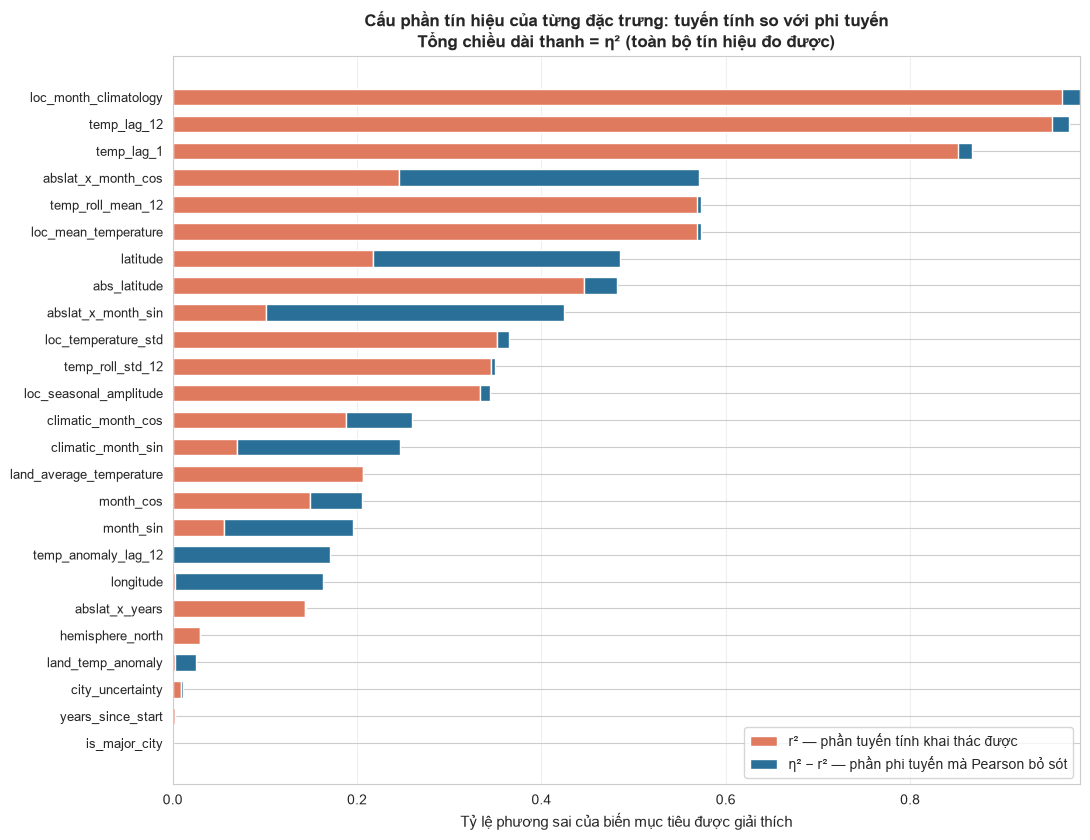

Năm đặc trưng có phần phi tuyến lớn nhất (mô hình tuyến tính khai thác được ít nhất):


,Nhóm,Pearson r,r2,eta2,Phi tuyến (eta2 - r2)
Feature,,,,,
abslat_x_month_cos,Tương tác,-0.4951,0.2451,0.5708,0.3257
abslat_x_month_sin,Tương tác,-0.3182,0.1013,0.4243,0.3231
latitude,Địa lý,-0.4667,0.2178,0.4853,0.2675
climatic_month_sin,Thời gian,-0.2638,0.0696,0.2467,0.1772
temp_anomaly_lag_12,Trễ / Trượt,0.0135,0.0002,0.1710,0.1708


In [23]:
plot_metrics = feature_metrics.dropna(subset=['eta2']).sort_values('eta2')

fig, ax = plt.subplots(figsize=(11, max(6, len(plot_metrics) * 0.34)))
y_positions = np.arange(len(plot_metrics))

# r² là phần mô hình tuyến tính khai thác được; phần còn lại tới η² là phi tuyến.
ax.barh(y_positions, plot_metrics['r2'], height=0.62,
        color='#e07a5f', label='r² — phần tuyến tính khai thác được')
ax.barh(y_positions, plot_metrics['eta2'] - plot_metrics['r2'], height=0.62,
        left=plot_metrics['r2'], color='#2a6f97',
        label='η² − r² — phần phi tuyến mà Pearson bỏ sót')

ax.set_yticks(y_positions)
ax.set_yticklabels(plot_metrics.index, fontsize=9)
ax.set_xlabel('Tỷ lệ phương sai của biến mục tiêu được giải thích', fontsize=11)
ax.set_title('Cấu phần tín hiệu của từng đặc trưng: tuyến tính so với phi tuyến\n'
             'Tổng chiều dài thanh = η² (toàn bộ tín hiệu đo được)',
             fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(REPORT_IMAGES_DIR / '08_feature_signal_comparison.png', dpi=200,
            bbox_inches='tight')
print('Đã lưu: reports/images/08_feature_signal_comparison.png')
plt.show()

print('Năm đặc trưng có phần phi tuyến lớn nhất '
      '(mô hình tuyến tính khai thác được ít nhất):')
display(
    feature_metrics.nlargest(5, 'Phi tuyến (eta2 - r2)')[
        ['Nhóm', 'Pearson r', 'r2', 'eta2', 'Phi tuyến (eta2 - r2)']
    ]
)

Mỗi thanh trên biểu đồ được chia thành hai phần: phần cam là `r²` — lượng tín hiệu mà một mô hình tuyến tính khai thác được; phần xanh là `η² − r²` — lượng tín hiệu chỉ mô hình phi tuyến mới lấy được.

Đây là kết luận có ý nghĩa trực tiếp cho Notebook 06: nếu phần xanh chiếm tỷ trọng lớn ở nhiều đặc trưng quan trọng, thì hồi quy tuyến tính (Linear Regression, Ridge, Lasso) sẽ **thua rõ rệt** so với các mô hình dạng cây (Decision Tree, Random Forest, Gradient Boosting) — và đó là điều cần được kiểm chứng bằng số liệu ở Notebook 06 thay vì phỏng đoán trước.

### 6.3. Feature Importance

Tương quan chỉ đo liên hệ của **từng** đặc trưng với target một cách riêng lẻ. Feature importance đo mức đóng góp của đặc trưng khi **các đặc trưng khác cùng có mặt**, nên phát hiện được trường hợp một đặc trưng mạnh nhưng chỉ lặp lại thông tin của đặc trưng khác.

Notebook dùng Random Forest trên một mẫu nhỏ. `scikit-learn` là phụ thuộc tùy chọn: nếu chưa cài, cell in hướng dẫn cài đặt và bỏ qua, phần đánh giá vẫn đầy đủ nhờ η² ở Mục 6.2 — notebook không bị dừng giữa dòng.

Huấn luyện Random Forest trên 120,000 dòng đầy đủ giá trị (30.0% mẫu đánh giá)...
R² trên chính tập vừa huấn luyện: 0.9898  (chỉ để tham khảo, không phải chỉ số đánh giá mô hình)


,importance
loc_month_climatology,0.9946
land_temp_anomaly,0.0017
years_since_start,0.0008
temp_lag_1,0.0004
temp_lag_12,0.0003
abslat_x_years,0.0003
city_uncertainty,0.0002
land_average_temperature,0.0002
temp_roll_std_12,0.0002
temp_roll_mean_12,0.0002


Đã lưu: reports/images/09_feature_importance.png


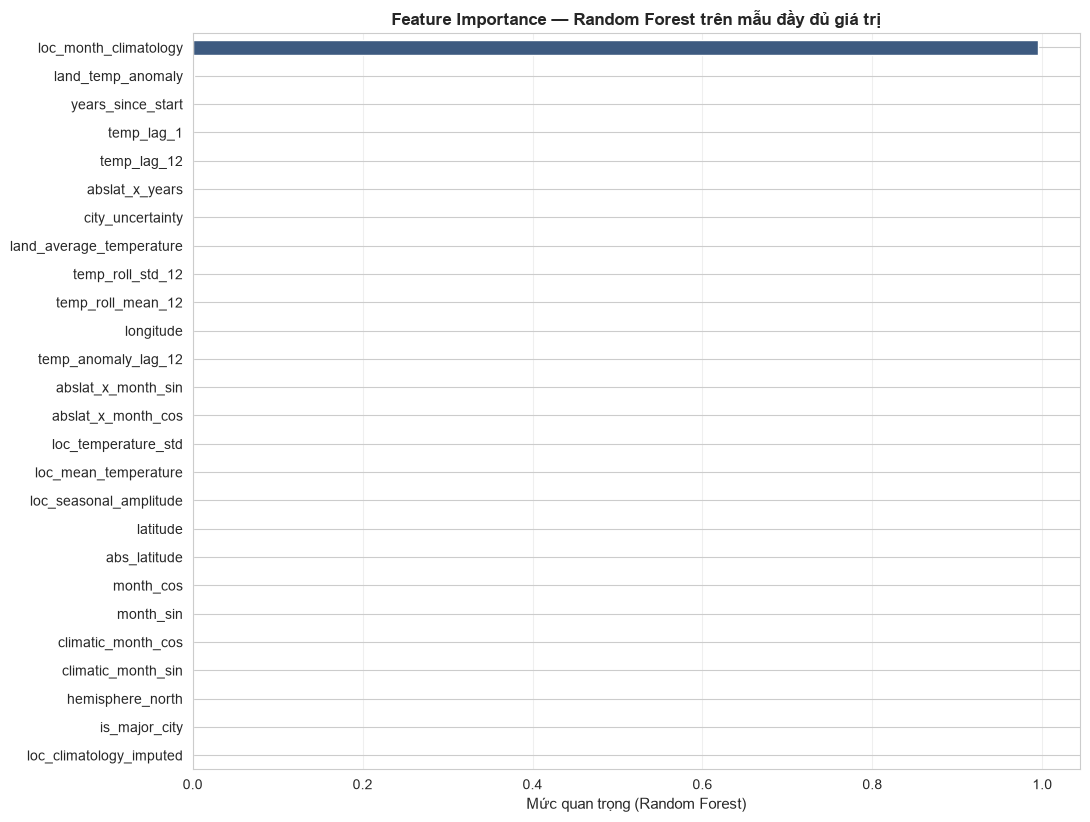

In [24]:
IMPORTANCE_SAMPLE_ROWS = 120_000
feature_importance = None

try:
    from sklearn.ensemble import RandomForestRegressor
    HAS_SKLEARN = True
except ImportError:
    HAS_SKLEARN = False

if not HAS_SKLEARN:
    print('scikit-learn chưa được cài nên bỏ qua Feature Importance.')
    print('Cài đặt bằng:  python -m pip install scikit-learn')
    print('Phần đánh giá vẫn đầy đủ nhờ η² ở Mục 6.2.')
else:
    # Random Forest không nhận NaN, nên chỉ dùng các dòng có đủ mọi đặc trưng.
    dense_df = eval_df[CANDIDATE_FEATURES + [TARGET_COLUMN]].dropna()
    if len(dense_df) > IMPORTANCE_SAMPLE_ROWS:
        dense_df = dense_df.sample(n=IMPORTANCE_SAMPLE_ROWS, random_state=RANDOM_SEED)

    print(f'Huấn luyện Random Forest trên {len(dense_df):,} dòng đầy đủ giá trị '
          f'({len(dense_df) / len(eval_df):.1%} mẫu đánh giá)...')
    forest = RandomForestRegressor(
        n_estimators=60,
        max_depth=14,
        min_samples_leaf=20,
        n_jobs=-1,
        random_state=RANDOM_SEED,
    )
    forest.fit(dense_df[CANDIDATE_FEATURES], dense_df[TARGET_COLUMN])

    feature_importance = (
        pd.Series(forest.feature_importances_, index=CANDIDATE_FEATURES, name='importance')
        .sort_values(ascending=False)
    )
    print(f'R² trên chính tập vừa huấn luyện: {forest.score(dense_df[CANDIDATE_FEATURES], dense_df[TARGET_COLUMN]):.4f}'
          '  (chỉ để tham khảo, không phải chỉ số đánh giá mô hình)')
    display(feature_importance.to_frame())

    fig, ax = plt.subplots(figsize=(11, max(6, len(feature_importance) * 0.32)))
    feature_importance.sort_values().plot.barh(ax=ax, color='#3d5a80')
    ax.set_xlabel('Mức quan trọng (Random Forest)', fontsize=11)
    ax.set_title('Feature Importance — Random Forest trên mẫu đầy đủ giá trị',
                 fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.savefig(REPORT_IMAGES_DIR / '09_feature_importance.png', dpi=200, bbox_inches='tight')
    print('Đã lưu: reports/images/09_feature_importance.png')
    plt.show()

Nếu cell chạy được, cần lưu ý hai điều khi đọc kết quả. Thứ nhất, `R²` in ra được tính trên chính tập vừa huấn luyện nên luôn lạc quan; đây **không** phải chỉ số đánh giá mô hình — việc đó thuộc Notebook 06 với tập test tách theo thời gian. Thứ hai, importance của Random Forest bị chia đều giữa các đặc trưng trùng lặp thông tin, nên một đặc trưng có importance thấp chưa hẳn vô dụng; cần đọc cùng bảng đa cộng tuyến ở Mục 6.4.

Việc phải bỏ các dòng thiếu giá trị cũng khiến tập này nghiêng về giai đoạn sau của dữ liệu — nơi các đặc trưng trễ đã có đủ quá khứ.

### 6.4. Kiểm tra đa cộng tuyến giữa các đặc trưng

Notebook 04 đã cảnh báo về đa cộng tuyến trong nhóm `land_*` (`r > 0.98`). Nhóm đó đã được xử lý từ bước đọc dữ liệu, nhưng chính quá trình tạo đặc trưng cũng có thể sinh ra trùng lặp mới — ví dụ `loc_mean_temperature` và `loc_month_climatology`, hoặc `city_uncertainty` và `years_since_start`.

Cell dưới liệt kê mọi cặp có `|r| > REDUNDANCY_THRESHOLD`. Đây là đầu vào cho quy tắc lược bỏ ở Mục 7.

In [25]:
correlation_matrix = eval_df[CANDIDATE_FEATURES].corr()

upper_triangle = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)
redundant_pairs = (
    upper_triangle.stack()
    .rename('Pearson r')
    .reset_index()
    .rename(columns={'level_0': 'Feature A', 'level_1': 'Feature B'})
)
redundant_pairs['|r|'] = redundant_pairs['Pearson r'].abs()
redundant_pairs = (
    redundant_pairs[redundant_pairs['|r|'] > REDUNDANCY_THRESHOLD]
    .sort_values('|r|', ascending=False)
    .reset_index(drop=True)
)

print(f'Ngưỡng trùng lặp: |r| > {REDUNDANCY_THRESHOLD}')
if redundant_pairs.empty:
    print('Không có cặp đặc trưng nào vượt ngưỡng trùng lặp.')
else:
    print(f'Có {len(redundant_pairs)} cặp vượt ngưỡng:')
    display(redundant_pairs[['Feature A', 'Feature B', 'Pearson r']])

Ngưỡng trùng lặp: |r| > 0.95
Có 5 cặp vượt ngưỡng:


,Feature A,Feature B,Pearson r
0,loc_temperature_std,loc_seasonal_amplitude,0.9981
1,loc_mean_temperature,temp_roll_mean_12,0.9968
2,loc_temperature_std,temp_roll_std_12,0.9922
3,loc_month_climatology,temp_lag_12,0.9921
4,loc_seasonal_amplitude,temp_roll_std_12,0.9907


Mỗi cặp xuất hiện ở đây nghĩa là hai đặc trưng gần như mang cùng một thông tin. Giữ cả hai không làm mô hình chính xác hơn nhưng làm hệ số của mô hình tuyến tính mất ổn định và làm importance của mô hình cây bị chia nhỏ. Mục 7 sẽ giữ lại đặc trưng có `eta2` cao hơn trong mỗi cặp.

### 6.5. Kiểm tra rò rỉ dữ liệu

Mục này thực hiện ba phép thử tự động thay vì chỉ tin vào cam kết ở Mục 4.2.

**Phép thử 1 — chứng minh rò rỉ của hai cột bị loại.** Notebook 04 báo `major_city_average_temperature` có `r = 1.000` với target. Cell dưới đo lại ngay trên dữ liệu để làm rõ vì sao cả nó và `country_average_temperature` bị loại, thay vì chỉ nói rằng chúng bị loại.

**Phép thử 2 — đặc trưng trễ chỉ nhìn quá khứ.** Lấy mẫu vài nghìn dòng và kiểm tra `temp_lag_12` tại tháng `t` có đúng bằng target tại tháng `t − 12` của cùng vị trí hay không.

**Phép thử 3 — không đặc trưng nào trùng khớp target.** Bất kỳ đặc trưng nào có `|r| > 0.999` với target đều là dấu hiệu rò rỉ và làm notebook dừng lại.

In [26]:
# --- Phép thử 1: mức tương quan của các cột bị loại --------------------
leakage_candidates = ['major_city_average_temperature', 'country_average_temperature']
leakage_rows = []
for column in leakage_candidates:
    valid = eval_df[column].notna() & eval_target.notna()
    leakage_rows.append(
        {
            'Cột nguồn': column,
            'Số dòng có giá trị': int(valid.sum()),
            'Tỷ lệ có giá trị': float(valid.mean()),
            'Pearson r với target': float(eval_df.loc[valid, column].corr(eval_target[valid]))
            if valid.sum() > 1 else float('nan'),
        }
    )
display(pd.DataFrame(leakage_rows).set_index('Cột nguồn'))
print('→ Cả hai cột đều là phép đo nhiệt độ CÙNG THÁNG và đã bao gồm chính thành phố '
      'đang dự báo, nên không được dùng làm đặc trưng.')

,Số dòng có giá trị,Tỷ lệ có giá trị,Pearson r với target
Cột nguồn,,,
major_city_average_temperature,10840,0.0271,1.0000
country_average_temperature,399567,0.9989,0.8970


→ Cả hai cột đều là phép đo nhiệt độ CÙNG THÁNG và đã bao gồm chính thành phố đang dự báo, nên không được dùng làm đặc trưng.


In [27]:
# --- Phép thử 2: temp_lag_12 phải khớp target của 12 tháng trước -------
check_frame = feature_df[['location_key', TARGET_COLUMN, 'temp_lag_12']]
verify_pool = check_frame[check_frame['temp_lag_12'].notna()]
verify_size = min(5_000, len(verify_pool))
verify_sample = verify_pool.sample(n=verify_size, random_state=RANDOM_SEED)

truth_lookup = pd.Series(
    feature_df[TARGET_COLUMN].to_numpy(), index=feature_df['location_key'].to_numpy()
)
expected_lag = truth_lookup.reindex(verify_sample['location_key'].to_numpy() - 12).to_numpy()
lag_matches = np.allclose(
    verify_sample['temp_lag_12'].to_numpy(dtype='float64'),
    expected_lag.astype('float64'),
    equal_nan=True,
)

print(f'Kiểm tra {verify_size:,} dòng ngẫu nhiên: temp_lag_12 khớp target của 12 tháng trước '
      f'→ {"PASS" if lag_matches else "FAIL"}')
if not lag_matches:
    raise RuntimeError('temp_lag_12 không khớp giá trị quá khứ; đặc trưng trễ bị sai mốc.')

# Không đặc trưng trễ nào được trùng chính target của cùng tháng.
same_month_leak = [
    name for name in ('temp_lag_1', 'temp_lag_12', 'temp_roll_mean_12')
    if np.isclose(
        feature_df[name].corr(feature_df[TARGET_COLUMN]), 1.0, atol=1e-6
    )
]
print(f'Đặc trưng trễ trùng khớp target: {same_month_leak or "không có"}')

Kiểm tra 5,000 dòng ngẫu nhiên: temp_lag_12 khớp target của 12 tháng trước → PASS
Đặc trưng trễ trùng khớp target: không có


In [28]:
# --- Phép thử 3: không đặc trưng nào có |r| > 0.999 với target ---------
LEAKAGE_CORRELATION_LIMIT = 0.999
suspicious = feature_metrics[feature_metrics['|Pearson|'] > LEAKAGE_CORRELATION_LIMIT]

if suspicious.empty:
    print(f'PASS: không đặc trưng nào có |r| > {LEAKAGE_CORRELATION_LIMIT} với target.')
else:
    display(suspicious)
    raise RuntimeError(
        'Có đặc trưng trùng khớp gần như hoàn toàn với biến mục tiêu. '
        'Hãy kiểm tra lại cách tạo đặc trưng trước khi tiếp tục.'
    )

print(f'Cột suy ra từ target bị loại khỏi đặc trưng: temp_anomaly_vs_climatology '
      '(chỉ dùng phân tích ở Mục 8)')

PASS: không đặc trưng nào có |r| > 0.999 với target.
Cột suy ra từ target bị loại khỏi đặc trưng: temp_anomaly_vs_climatology (chỉ dùng phân tích ở Mục 8)


Ba phép thử `PASS` là căn cứ để khẳng định tập đặc trưng không rò rỉ, mạnh hơn nhiều so với việc chỉ trình bày nguyên tắc. Phép thử 2 đặc biệt quan trọng vì nó phát hiện được đúng loại lỗi mà `shift()` theo số dòng gây ra trên dữ liệu có khoảng trống tháng.

### 6.6. SHAP (nâng cao, tùy chọn)

SHAP phân bổ phần đóng góp của từng đặc trưng vào **từng dự báo cụ thể**, thay vì chỉ đưa ra một con số quan trọng chung cho toàn mô hình. Nhờ đó có thể trả lời những câu hỏi như: với một thành phố ở vĩ độ cao vào tháng 1, đặc trưng nào đã kéo dự báo xuống thấp.

Đây là phần nâng cao và `shap` không nằm trong `requirements.txt`, nên cell dưới chỉ chạy khi thư viện đã được cài; nếu không, notebook bỏ qua và đi tiếp.

In [29]:
try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False

if not (HAS_SHAP and HAS_SKLEARN and feature_importance is not None):
    print('Bỏ qua SHAP (cần cả shap và scikit-learn).')
    print('Nếu muốn dùng:  python -m pip install shap')
else:
    shap_sample = dense_df.sample(n=min(2_000, len(dense_df)), random_state=RANDOM_SEED)
    explainer = shap.TreeExplainer(forest)
    shap_values = explainer.shap_values(shap_sample[CANDIDATE_FEATURES], check_additivity=False)
    mean_abs_shap = (
        pd.Series(np.abs(shap_values).mean(axis=0), index=CANDIDATE_FEATURES,
                  name='mean |SHAP| (°C)')
        .sort_values(ascending=False)
    )
    display(mean_abs_shap.to_frame())
    print('Giá trị đọc là: trung bình mức dịch chuyển dự báo (°C) do đặc trưng đó gây ra.')

Bỏ qua SHAP (cần cả shap và scikit-learn).
Nếu muốn dùng:  python -m pip install shap


## 7. Lựa chọn Feature

### 7.1. Bộ quy tắc lựa chọn

Việc giữ hay loại được quyết định bằng **bộ quy tắc định lượng công khai**, áp dụng theo thứ tự, thay vì gán tay từng đặc trưng. Cách này khiến kết quả có thể tái lập và kiểm chứng được.

1. **Giữ bắt buộc.** Các đặc trưng đánh dấu `force_keep` luôn được giữ, kèm lý do ghi rõ trong bảng quyết định. Có hai trường hợp: các cặp mã hóa tuần hoàn `sin`/`cos` (chỉ có nghĩa khi đi cùng nhau, vì một mình `sin` không phân biệt được tháng 3 với tháng 9), và `years_since_start` (biến trọng tâm của bài toán biến đổi khí hậu — tín hiệu biên của nó nhỏ vì bị mùa vụ che lấp, nhưng loại nó đi thì mô hình không còn cách nào tách được xu hướng dài hạn).
2. **Loại cột hằng số.** Cột chỉ có một giá trị duy nhất không mang thông tin phân biệt và làm mọi chỉ số trở thành `NaN`.
3. **Loại nếu tín hiệu quá yếu.** Loại khi `eta2 < 0.005` **và** `|Pearson| < 0.05`. Phải thỏa mãn **cả hai** điều kiện, để không loại oan các đặc trưng phi tuyến có Pearson thấp nhưng η² cao — chính là trường hợp `latitude` ở Mục 6.2.
4. **Loại nếu trùng lặp thông tin.** Trong mỗi cặp `|r| > 0.95`, giữ đặc trưng có `eta2` cao hơn và loại đặc trưng còn lại.
5. **Giữ trong các trường hợp còn lại.**

Riêng các cột bị loại vì lý do **ngữ nghĩa** (rò rỉ, suy ra từ target, trùng lặp đã biết từ Notebook 04) không tham gia bộ quy tắc này — chúng chưa từng được đưa vào danh sách ứng viên, và được ghi lại riêng ở Mục 7.3 để bảng quyết định phản ánh đầy đủ lập luận.

In [30]:
selection_records = {
    name: {'decision': 'Giữ', 'reason': 'Đạt ngưỡng tín hiệu và không trùng lặp.'}
    for name in CANDIDATE_FEATURES
}

# --- Quy tắc 1 và 2: giữ bắt buộc, cột hằng số, tín hiệu quá yếu -------
for name in CANDIDATE_FEATURES:
    if FEATURE_CATALOG[name]['force_keep']:
        selection_records[name] = {
            'decision': 'Giữ',
            'reason': f"Giữ bắt buộc. {FEATURE_CATALOG[name]['keep_reason']}",
        }
        continue

    # Cột hằng số (hoặc toàn NaN) không có phương sai nên mọi chỉ số đều là NaN.
    if eval_df[name].nunique(dropna=True) < 2:
        selection_records[name] = {
            'decision': 'Loại',
            'reason': 'Cột hằng số trên dữ liệu hiện tại nên không mang thông tin phân biệt.',
        }
        continue

    eta = feature_metrics.loc[name, 'eta2']
    abs_pearson = feature_metrics.loc[name, '|Pearson|']
    eta_weak = not (eta == eta) or eta < MIN_ETA_SQUARED
    pearson_weak = not (abs_pearson == abs_pearson) or abs_pearson < MIN_ABS_PEARSON
    if eta_weak and pearson_weak:
        selection_records[name] = {
            'decision': 'Loại',
            'reason': f'Tín hiệu quá yếu (η²={eta:.4f} < {MIN_ETA_SQUARED}, '
                      f'|r|={abs_pearson:.4f} < {MIN_ABS_PEARSON}).',
        }

# --- Quy tắc 3: trùng lặp thông tin ------------------------------------
for _, pair in redundant_pairs.iterrows():
    first, second = pair['Feature A'], pair['Feature B']
    if selection_records[first]['decision'] == 'Loại' or selection_records[second]['decision'] == 'Loại':
        continue
    first_eta = feature_metrics.loc[first, 'eta2']
    second_eta = feature_metrics.loc[second, 'eta2']
    weaker = first if (second_eta > first_eta or not (first_eta == first_eta)) else second
    stronger = second if weaker == first else first
    if FEATURE_CATALOG[weaker]['force_keep']:
        continue
    selection_records[weaker] = {
        'decision': 'Loại',
        'reason': f'Trùng lặp thông tin với {stronger} (r={pair["Pearson r"]:.4f}); '
                  f'{stronger} có η² cao hơn.',
    }

SELECTED_FEATURES = [
    name for name in CANDIDATE_FEATURES if selection_records[name]['decision'] == 'Giữ'
]
DROPPED_FEATURES = [
    name for name in CANDIDATE_FEATURES if selection_records[name]['decision'] == 'Loại'
]

print(f'Đặc trưng ứng viên : {len(CANDIDATE_FEATURES)}')
print(f'Giữ lại            : {len(SELECTED_FEATURES)}')
print(f'Loại bỏ            : {len(DROPPED_FEATURES)}')

Đặc trưng ứng viên : 26
Giữ lại            : 20
Loại bỏ            : 6


### 7.2. Bảng quyết định giữ / loại

In [31]:
decision_table = feature_metrics.join(
    pd.DataFrame(
        [
            {
                'Feature': name,
                'Khả dụng': FEATURE_CATALOG[name]['availability'],
                'Kết quả': selection_records[name]['decision'],
                'Lý do': selection_records[name]['reason'],
            }
            for name in CANDIDATE_FEATURES
        ]
    ).set_index('Feature')
)
decision_table = decision_table[
    ['Nhóm', 'Khả dụng', 'Pearson r', 'r2', 'Spearman', 'eta2', 'Kết quả', 'Lý do']
].sort_values(['Kết quả', 'eta2'], ascending=[True, False])

display(decision_table)
display(
    decision_table.groupby(['Nhóm', 'Kết quả'], observed=True)
    .size()
    .unstack(fill_value=0)
)

,Nhóm,Khả dụng,Pearson r,r2,Spearman,eta2,Kết quả,Lý do
Feature,,,,,,,,
loc_month_climatology,Khí hậu theo vị trí,train_stat,0.9921,0.9843,0.9924,0.9650,Giữ,Đạt ngưỡng tín hiệu và không trùng lặp.
temp_lag_1,Trễ / Trượt,history,0.9309,0.8666,0.9336,0.8521,Giữ,Đạt ngưỡng tín hiệu và không trùng lặp.
abslat_x_month_cos,Tương tác,static,-0.4951,0.2451,-0.4245,0.5708,Giữ,Đạt ngưỡng tín hiệu và không trùng lặp.
temp_roll_mean_12,Trễ / Trượt,history,0.7571,0.5733,0.7843,0.5688,Giữ,Đạt ngưỡng tín hiệu và không trùng lặp.
latitude,Địa lý,static,-0.4667,0.2178,-0.5845,0.4853,Giữ,Đạt ngưỡng tín hiệu và không trùng lặp.
abs_latitude,Địa lý,static,-0.6681,0.4463,-0.7035,0.4822,Giữ,Đạt ngưỡng tín hiệu và không trùng lặp.
abslat_x_month_sin,Tương tác,static,-0.3182,0.1013,-0.2926,0.4243,Giữ,Đạt ngưỡng tín hiệu và không trùng lặp.
loc_temperature_std,Khí hậu theo vị trí,train_stat,-0.5932,0.3519,-0.5694,0.3648,Giữ,Đạt ngưỡng tín hiệu và không trùng lặp.
climatic_month_cos,Thời gian,static,-0.4341,0.1884,-0.3900,0.2600,Giữ,Giữ bắt buộc. Thành phần của cặp mã hóa tuần h...


Kết quả,Giữ,Loại
Nhóm,,
Bối cảnh toàn cầu,2,0
Chất lượng dữ liệu,1,0
Khí hậu theo vị trí,2,3
Thời gian,5,0
Trễ / Trượt,3,2
Tương tác,3,0
Địa lý,4,1


Bảng này là sản phẩm chính của Mục 7: mỗi đặc trưng đều có số liệu kèm lý do giữ hoặc loại, thể hiện tư duy chọn lọc thay vì giữ lại tất cả. Bảng chéo phía dưới cho biết nhóm nào đóng góp nhiều đặc trưng hữu ích nhất và nhóm nào gần như bị loại hết — thông tin đáng đưa vào báo cáo cuối.

### 7.3. Các cột bị loại vì lý do ngữ nghĩa

Ngoài các đặc trưng bị bộ quy tắc loại, một số cột của bảng sạch bị loại vì lý do bản chất chứ không vì số liệu yếu. Nhiều cột trong đó thậm chí không được đọc vào bộ nhớ ở Mục 3.2.

In [32]:
SEMANTIC_EXCLUSIONS = [
    {
        'Cột': 'major_city_average_temperature',
        'Lý do loại': 'Rò rỉ: r = 1.000 với target, chỉ có giá trị ở 2,7% dòng (Notebook 04).',
    },
    {
        'Cột': 'country_average_temperature',
        'Lý do loại': 'Trung bình cùng tháng của quốc gia, đã bao gồm chính thành phố cần dự báo.',
    },
    {
        'Cột': 'land_max_temperature / land_min_temperature / land_and_ocean_average_temperature',
        'Lý do loại': 'r > 0.98 với land_average_temperature (Notebook 04); không đọc vào bộ nhớ.',
    },
    {
        'Cột': 'month / quarter / decade (dạng số nguyên thô)',
        'Lý do loại': 'Quan hệ tuần hoàn nên đã được thay bằng mã hóa sin/cos và years_since_start.',
    },
    {
        'Cột': 'city_temperature_iqr_outlier',
        'Lý do loại': 'Cờ phân tích chất lượng của Notebook 03, không phải biến dự báo.',
    },
    {
        'Cột': 'latitude_zone / climatic_season',
        'Lý do loại': 'Chỉ dùng để phân tích; thông tin đã có trong abs_latitude và mã hóa tuần hoàn.',
    },
    {
        'Cột': 'temp_anomaly_vs_climatology',
        'Lý do loại': 'Suy ra trực tiếp từ target nên không thể làm đặc trưng; chỉ dùng ở Mục 8.',
    },
]
display(pd.DataFrame(SEMANTIC_EXCLUSIONS).set_index('Cột'))

print('Danh sách đặc trưng cuối cùng:')
for index, name in enumerate(SELECTED_FEATURES, start=1):
    meta = FEATURE_CATALOG[name]
    print(f'  {index:2d}. {name:26s} [{meta["group"]} · {meta["availability"]}]')

,Lý do loại
Cột,
major_city_average_temperature,"Rò rỉ: r = 1.000 với target, chỉ có giá trị ở ..."
country_average_temperature,"Trung bình cùng tháng của quốc gia, đã bao gồm..."
land_max_temperature / land_min_temperature / land_and_ocean_average_temperature,r > 0.98 với land_average_temperature (Noteboo...
month / quarter / decade (dạng số nguyên thô),Quan hệ tuần hoàn nên đã được thay bằng mã hóa...
city_temperature_iqr_outlier,"Cờ phân tích chất lượng của Notebook 03, không..."
latitude_zone / climatic_season,Chỉ dùng để phân tích; thông tin đã có trong a...
temp_anomaly_vs_climatology,Suy ra trực tiếp từ target nên không thể làm đ...


Danh sách đặc trưng cuối cùng:
   1. month_sin                  [Thời gian · static]
   2. month_cos                  [Thời gian · static]
   3. climatic_month_sin         [Thời gian · static]
   4. climatic_month_cos         [Thời gian · static]
   5. years_since_start          [Thời gian · static]
   6. latitude                   [Địa lý · static]
   7. abs_latitude               [Địa lý · static]
   8. hemisphere_north           [Địa lý · static]
   9. longitude                  [Địa lý · static]
  10. abslat_x_month_sin         [Tương tác · static]
  11. abslat_x_month_cos         [Tương tác · static]
  12. abslat_x_years             [Tương tác · static]
  13. loc_month_climatology      [Khí hậu theo vị trí · train_stat]
  14. loc_temperature_std        [Khí hậu theo vị trí · train_stat]
  15. temp_lag_1                 [Trễ / Trượt · history]
  16. temp_roll_mean_12          [Trễ / Trượt · history]
  17. temp_anomaly_lag_12        [Trễ / Trượt · history]
  18. land_average_tempera

Danh sách in ra chính là thứ tự đặc trưng sẽ được ghi vào `feature_metadata.json` ở Mục 9.3. Notebook 06 phải đọc đúng danh sách và đúng thứ tự này, vì mô hình sau khi huấn luyện chỉ nhận đầu vào theo một thứ tự cột cố định.

## 8. Insight mới từ tập đặc trưng

Tập đặc trưng vừa xây dựng cho phép trả lời những câu hỏi mà Notebook 04 chưa trả lời được. Mục này khai thác `temp_anomaly_vs_climatology` — phần nhiệt độ lệch khỏi mức bình thường của chính thành phố đó trong tháng đó.

Cột này **không được dùng làm đặc trưng** vì nó suy ra trực tiếp từ target. Nhưng chính vì thế nó là công cụ phân tích tốt: nó đã loại bỏ hoàn toàn ảnh hưởng của mùa vụ và của vị trí, nên phần còn lại chủ yếu là tín hiệu biến đổi khí hậu.

Đã lưu: reports/images/10_anomaly_by_latitude_zone.png


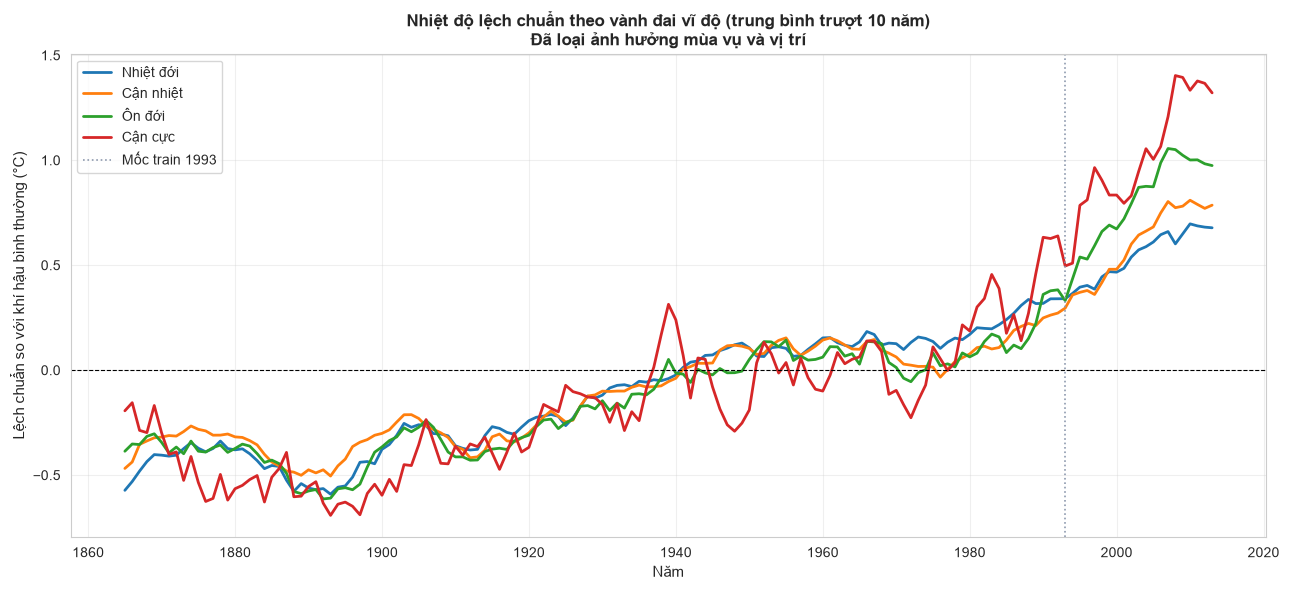

In [33]:
feature_df['temp_anomaly_vs_climatology'] = (
    feature_df[TARGET_COLUMN] - feature_df['loc_month_climatology']
).astype('float32')

anomaly_by_zone_year = (
    feature_df.groupby(['latitude_zone', 'year'], observed=True)[
        'temp_anomaly_vs_climatology'
    ]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 6))
for zone, zone_data in anomaly_by_zone_year.groupby('latitude_zone', observed=True):
    smoothed = zone_data.set_index('year')['temp_anomaly_vs_climatology'].rolling(
        10, min_periods=3
    ).mean()
    ax.plot(smoothed.index, smoothed.to_numpy(), linewidth=2, label=str(zone))

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.axvline(TRAIN_CUTOFF_YEAR, color='#8d99ae', linewidth=1.2, linestyle=':',
           label=f'Mốc train {TRAIN_CUTOFF_YEAR}')
ax.set_xlabel('Năm', fontsize=11)
ax.set_ylabel('Lệch chuẩn so với khí hậu bình thường (°C)', fontsize=11)
ax.set_title('Nhiệt độ lệch chuẩn theo vành đai vĩ độ (trung bình trượt 10 năm)\n'
             'Đã loại ảnh hưởng mùa vụ và vị trí',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(REPORT_IMAGES_DIR / '10_anomaly_by_latitude_zone.png', dpi=200,
            bbox_inches='tight')
print('Đã lưu: reports/images/10_anomaly_by_latitude_zone.png')
plt.show()

In [34]:
def warming_rate(group: pd.DataFrame) -> float:
    """Độ dốc °C/năm của lệch chuẩn nhiệt độ theo năm."""
    if len(group) < 10:
        return float('nan')
    slope, _ = np.polyfit(group['year'].to_numpy(dtype='float64'),
                          group['temp_anomaly_vs_climatology'].to_numpy(dtype='float64'), 1)
    return float(slope)


warming_by_zone = (
    anomaly_by_zone_year.groupby('latitude_zone', observed=True)[
        ['year', 'temp_anomaly_vs_climatology']
    ]
    .apply(warming_rate)
    .sort_values(ascending=False)
    .to_frame('Tốc độ ấm lên (°C/năm)')
    .rename_axis('Vành đai vĩ độ')
)
warming_by_zone['Trên 100 năm (°C)'] = warming_by_zone['Tốc độ ấm lên (°C/năm)'] * 100
display(warming_by_zone)

overall_slope = warming_rate(
    feature_df.groupby('year', observed=True)['temp_anomaly_vs_climatology']
    .mean()
    .reset_index()
)
print(f'Tốc độ ấm lên toàn tập (trên lệch chuẩn): {overall_slope:.4f} °C/năm')
print('So sánh: Notebook 04 đo trên nhiệt độ thô được +0.0269 °C/năm.')

,Tốc độ ấm lên (°C/năm),Trên 100 năm (°C)
Vành đai vĩ độ,,
Cận cực,0.0112,1.1215
Ôn đới,0.0091,0.9078
Nhiệt đới,0.0080,0.7997
Cận nhiệt,0.0075,0.7506


Tốc độ ấm lên toàn tập (trên lệch chuẩn): 0.0083 °C/năm
So sánh: Notebook 04 đo trên nhiệt độ thô được +0.0269 °C/năm.


Hai kết quả trên bổ sung cho Notebook 04 theo hai hướng.

Thứ nhất, tốc độ ấm lên đo **trên lệch chuẩn** đáng tin hơn con số đo trên nhiệt độ thô. Notebook 04 đã lưu ý một vấn đề độ phủ dữ liệu: số thành phố được ghi nhận tăng dần theo thời gian, nên trung bình nhiệt độ thô theo năm bị ảnh hưởng bởi việc *thành phố nào* có mặt trong năm đó. Vì lệch chuẩn được tính so với mức bình thường của từng thành phố, việc thêm hay bớt thành phố ảnh hưởng ít hơn nhiều.

Thứ hai, bảng theo vành đai vĩ độ cho biết khu vực nào ấm lên nhanh hơn — thông tin mà một con số trung bình toàn cầu không thể hiện được. Đường thẳng đứng ở mốc `TRAIN_CUTOFF_YEAR` trên biểu đồ cũng cho thấy trực quan phần dữ liệu mà Notebook 06 sẽ dùng để kiểm định nằm ở đâu.

## 9. Lưu dữ liệu mới

### 9.1. Chuẩn bị bảng đầu ra

Bảng đầu ra gồm bốn phần: khóa nghiệp vụ để truy vết, cột `year`/`month` để chia train/test, biến mục tiêu, và các đặc trưng đã được chọn ở Mục 7.

Ba loại cột **không** được lưu:

- Các đặc trưng bị loại ở Mục 7 — giữ lại chỉ làm file phình lên và tạo cơ hội dùng sai.
- `temp_anomaly_vs_climatology` và các cột phân tích — vì suy ra từ target, lưu ra file là tạo rủi ro rò rỉ cho Notebook 06.
- Các khóa kỹ thuật `location_key`, `month_index` — tái tạo được từ dữ liệu.

Cột `is_train_period` được thêm vào để Notebook 06 tái lập chính xác cách chia train/test đã dùng khi tính các đặc trưng thống kê.

In [35]:
OUTPUT_KEY_COLUMNS = [
    'observation_date', 'city_name', 'country_name', 'latitude', 'longitude',
    'year', 'month',
]
output_columns = (
    OUTPUT_KEY_COLUMNS
    + [TARGET_COLUMN]
    + [name for name in SELECTED_FEATURES if name not in OUTPUT_KEY_COLUMNS]
    + ['is_train_period']
)

feature_df['is_train_period'] = train_period_mask.astype('int8')
output_df = feature_df[output_columns]

print(f'Bảng đầu ra: {len(output_df):,} dòng × {output_df.shape[1]} cột')
print(f'Bộ nhớ      : {output_df.memory_usage(deep=True).sum() / 1024 ** 2:,.1f} MB')
display(output_df.head())

leaked = [
    column for column in output_df.columns
    if column in {'temp_anomaly_vs_climatology', 'major_city_average_temperature',
                  'country_average_temperature'}
]
if leaked:
    raise RuntimeError(f'Bảng đầu ra chứa cột rò rỉ: {leaked}')
print('PASS: bảng đầu ra không chứa cột rò rỉ.')

Bảng đầu ra: 5,579,085 dòng × 27 cột
Bộ nhớ      : 651.9 MB


,observation_date,city_name,country_name,latitude,longitude,year,month,city_average_temperature,month_sin,month_cos,climatic_month_sin,climatic_month_cos,years_since_start,abs_latitude,hemisphere_north,abslat_x_month_sin,abslat_x_month_cos,abslat_x_years,loc_month_climatology,loc_temperature_std,temp_lag_1,temp_roll_mean_12,temp_anomaly_lag_12,land_average_temperature,land_temp_anomaly,city_uncertainty,is_train_period
0,1863-01-01,A Coruña,Spain,42.5900,-8.7300,1863,1,8.1310,0.5000,0.8660,0.5000,0.8660,0,42.5900,1,21.2950,36.8840,0.0000,8.3395,3.8634,NaN,NaN,NaN,3.0340,0.4349,2.4300,1
1,1863-02-01,A Coruña,Spain,42.5900,-8.7300,1863,2,8.7000,0.8660,0.5000,0.8660,0.5000,0,42.5900,1,36.8840,21.2950,0.0000,9.0381,3.8634,8.1310,NaN,NaN,3.2530,0.1265,2.7820,1
2,1863-03-01,A Coruña,Spain,42.5900,-8.7300,1863,3,9.9850,1.0000,-0.0000,1.0000,-0.0000,0,42.5900,1,42.5900,-0.0000,0.0000,10.2491,3.8634,8.7000,NaN,NaN,4.6820,-0.5198,0.7800,1
3,1863-04-01,A Coruña,Spain,42.5900,-8.7300,1863,4,12.6010,0.8660,-0.5000,0.8660,-0.5000,0,42.5900,1,36.8840,-21.2950,0.0000,11.4962,3.8634,9.9850,NaN,NaN,7.9310,-0.4407,1.2260,1
4,1863-05-01,A Coruña,Spain,42.5900,-8.7300,1863,5,13.2300,0.5000,-0.8660,0.5000,-0.8660,0,42.5900,1,21.2950,-36.8840,0.0000,13.7989,3.8634,12.6010,NaN,NaN,11.0810,-0.1836,1.3180,1


PASS: bảng đầu ra không chứa cột rò rỉ.


### 9.2. Kiểm tra dung lượng và ghi file

Bảng đầu ra có hơn 5,5 triệu dòng nên file kết quả rất lớn: dạng CSV thô khoảng 1,3 GB, còn nén gzip chỉ khoảng 200–300 MB. Vì `data/processed/` đã chứa vài file dung lượng lớn từ các notebook trước, notebook **ước lượng và kiểm tra dung lượng trống trước khi ghi**, thay vì để thao tác ghi làm đầy ổ đĩa rồi thất bại giữa chừng.

Mặc định `OUTPUT_COMPRESSION = 'gzip'`. `pandas.read_csv()` đọc file `.csv.gz` trong suốt nên Notebook 06 không cần xử lý gì thêm. Nếu cần file `.csv` thô, đặt `OUTPUT_COMPRESSION = None` ở Mục 2.3 — với điều kiện còn đủ chỗ trống.

In [36]:
BYTES_PER_VALUE = 9          # ước lượng độ dài trung bình một giá trị trong CSV
GZIP_RATIO = 0.22            # tỷ lệ nén thực nghiệm với dữ liệu dạng số

raw_estimate = len(output_df) * output_df.shape[1] * BYTES_PER_VALUE
estimated_bytes = raw_estimate * (GZIP_RATIO if OUTPUT_COMPRESSION == 'gzip' else 1.0)
free_bytes = shutil.disk_usage(PROCESSED_DIR).free

print(f'Ước lượng kích thước file : {estimated_bytes / 1024 ** 3:,.2f} GB '
      f'({OUTPUT_COMPRESSION or "không nén"})')
print(f'Dung lượng trống          : {free_bytes / 1024 ** 3:,.2f} GB')

if free_bytes < estimated_bytes * 1.3:
    raise RuntimeError(
        f'Không đủ dung lượng trống để ghi {OUTPUT_PATH.name} '
        f'(cần ~{estimated_bytes * 1.3 / 1024 ** 3:.2f} GB, còn {free_bytes / 1024 ** 3:.2f} GB).\n'
        'Cách xử lý: đặt OUTPUT_COMPRESSION = "gzip" ở Mục 2.3, '
        'hoặc dọn bớt file lớn trong data/processed/.'
    )
print('PASS: đủ dung lượng để ghi file.')

Ước lượng kích thước file : 0.28 GB (gzip)
Dung lượng trống          : 2.58 GB
PASS: đủ dung lượng để ghi file.


In [37]:
output_df.to_csv(
    OUTPUT_PATH,
    index=False,
    encoding='utf-8',
    date_format='%Y-%m-%d',
    float_format='%.4f',
    compression=OUTPUT_COMPRESSION,
)

actual_size_mb = OUTPUT_PATH.stat().st_size / 1024 ** 2
print('Đã lưu:', OUTPUT_PATH)
print(f'Kích thước thực tế: {actual_size_mb:,.1f} MB')

# Đọc lại vài dòng đầu để xác nhận file hợp lệ và đúng thứ tự cột.
verify_df = pd.read_csv(OUTPUT_PATH, nrows=5)
if list(verify_df.columns) != output_columns:
    raise RuntimeError('Thứ tự cột trong file không khớp bảng đầu ra.')
print(f'PASS: đọc lại được {verify_df.shape[1]} cột đúng thứ tự.')
display(verify_df)

Đã lưu: E:\project1\Global-Surface-Temperature-Analysis\data\processed\feature_engineered_data.csv.gz
Kích thước thực tế: 198.8 MB
PASS: đọc lại được 27 cột đúng thứ tự.


,observation_date,city_name,country_name,latitude,longitude,year,month,city_average_temperature,month_sin,month_cos,climatic_month_sin,climatic_month_cos,years_since_start,abs_latitude,hemisphere_north,abslat_x_month_sin,abslat_x_month_cos,abslat_x_years,loc_month_climatology,loc_temperature_std,temp_lag_1,temp_roll_mean_12,temp_anomaly_lag_12,land_average_temperature,land_temp_anomaly,city_uncertainty,is_train_period
0,1863-01-01,A Coruña,Spain,42.5900,-8.7300,1863,1,8.1310,0.5000,0.8660,0.5000,0.8660,0,42.5900,1,21.2950,36.8840,0.0000,8.3395,3.8634,NaN,NaN,NaN,3.0340,0.4349,2.4300,1
1,1863-02-01,A Coruña,Spain,42.5900,-8.7300,1863,2,8.7000,0.8660,0.5000,0.8660,0.5000,0,42.5900,1,36.8840,21.2950,0.0000,9.0381,3.8634,8.1310,NaN,NaN,3.2530,0.1265,2.7820,1
2,1863-03-01,A Coruña,Spain,42.5900,-8.7300,1863,3,9.9850,1.0000,-0.0000,1.0000,-0.0000,0,42.5900,1,42.5900,-0.0000,0.0000,10.2491,3.8634,8.7000,NaN,NaN,4.6820,-0.5198,0.7800,1
3,1863-04-01,A Coruña,Spain,42.5900,-8.7300,1863,4,12.6010,0.8660,-0.5000,0.8660,-0.5000,0,42.5900,1,36.8840,-21.2950,0.0000,11.4962,3.8634,9.9850,NaN,NaN,7.9310,-0.4407,1.2260,1
4,1863-05-01,A Coruña,Spain,42.5900,-8.7300,1863,5,13.2300,0.5000,-0.8660,0.5000,-0.8660,0,42.5900,1,21.2950,-36.8840,0.0000,13.7989,3.8634,12.6010,NaN,NaN,11.0810,-0.1836,1.3180,1


`float_format='%.4f'` giới hạn 4 chữ số thập phân: dữ liệu nguồn chỉ có 3 chữ số nên không mất thông tin, mà tránh được việc `float32` in ra hàng chục chữ số vô nghĩa và làm file phình lên.

Bước đọc lại 5 dòng đầu là phép kiểm tra rẻ nhưng hiệu quả: nó xác nhận file ghi thành công, giải nén được và giữ đúng thứ tự cột mà Notebook 06 sẽ dựa vào.

### 9.3. Lưu metadata đặc trưng

File metadata là **hợp đồng dữ liệu** giữa Notebook 05 và Notebook 06. Nó ghi lại danh sách đặc trưng theo đúng thứ tự, biến mục tiêu, mốc `train_cutoff_year` và điều kiện khả dụng của từng đặc trưng.

Trường `train_cutoff_year` là trường quan trọng nhất: các đặc trưng khí hậu theo vị trí được tính từ dữ liệu tới năm đó, nên nếu Notebook 06 chia train/test tại một mốc khác thì sẽ phát sinh rò rỉ. Ghi mốc này ra file cho phép Notebook 06 kiểm tra bằng code thay vì dựa vào ghi nhớ.

In [38]:
feature_metadata = {
    'created_at': datetime.now(timezone.utc).isoformat(timespec='seconds'),
    'created_by': '05_feature_engineering.ipynb',
    'data_source': DATA_SOURCE,
    'fast_mode': FAST_MODE,
    'row_count': int(len(output_df)),
    'location_count': int(feature_df['location_id'].nunique()),
    'target': TARGET_COLUMN,
    'train_cutoff_year': int(TRAIN_CUTOFF_YEAR),
    'train_row_count': int(train_period_mask.sum()),
    'test_row_count': int((~train_period_mask).sum()),
    'observation_date_range': [
        str(feature_df['observation_date'].min().date()),
        str(feature_df['observation_date'].max().date()),
    ],
    'output_file': OUTPUT_PATH.name,
    'key_columns': OUTPUT_KEY_COLUMNS,
    'feature_names': SELECTED_FEATURES,
    'feature_details': {
        name: {
            'group': FEATURE_CATALOG[name]['group'],
            'availability': FEATURE_CATALOG[name]['availability'],
            'description': FEATURE_CATALOG[name]['description'],
            'pearson_r': round(float(feature_metrics.loc[name, 'Pearson r']), 6),
            'eta_squared': round(float(feature_metrics.loc[name, 'eta2']), 6),
        }
        for name in SELECTED_FEATURES
    },
    'dropped_features': {
        name: selection_records[name]['reason'] for name in DROPPED_FEATURES
    },
    'semantic_exclusions': {item['Cột']: item['Lý do loại'] for item in SEMANTIC_EXCLUSIONS},
    'selection_rules': {
        'min_eta_squared': MIN_ETA_SQUARED,
        'min_abs_pearson': MIN_ABS_PEARSON,
        'redundancy_threshold': REDUNDANCY_THRESHOLD,
    },
    'notes_for_notebook_06': [
        'Chia train/test theo is_train_period hoặc year <= train_cutoff_year; '
        'không dùng chia ngẫu nhiên vì đây là dữ liệu chuỗi thời gian.',
        'Các đặc trưng availability=history có giá trị thiếu ở đầu chuỗi mỗi thành phố; '
        'hãy loại các dòng đó hoặc dùng mô hình chấp nhận NaN.',
        'Dùng feature_names theo đúng thứ tự đã ghi khi huấn luyện và khi dự báo.',
    ],
}

METADATA_PATH.write_text(
    json.dumps(feature_metadata, ensure_ascii=False, indent=2), encoding='utf-8'
)
print('Đã lưu:', METADATA_PATH)
print(f'Số đặc trưng ghi trong metadata: {len(feature_metadata["feature_names"])}')
print(json.dumps(
    {key: feature_metadata[key] for key in
     ('target', 'train_cutoff_year', 'row_count', 'output_file', 'feature_names')},
    ensure_ascii=False, indent=2,
))

Đã lưu: E:\project1\Global-Surface-Temperature-Analysis\data\processed\feature_metadata.json
Số đặc trưng ghi trong metadata: 20
{
  "target": "city_average_temperature",
  "train_cutoff_year": 1993,
  "row_count": 5579085,
  "output_file": "feature_engineered_data.csv.gz",
  "feature_names": [
    "month_sin",
    "month_cos",
    "climatic_month_sin",
    "climatic_month_cos",
    "years_since_start",
    "latitude",
    "abs_latitude",
    "hemisphere_north",
    "longitude",
    "abslat_x_month_sin",
    "abslat_x_month_cos",
    "abslat_x_years",
    "loc_month_climatology",
    "loc_temperature_std",
    "temp_lag_1",
    "temp_roll_mean_12",
    "temp_anomaly_lag_12",
    "land_average_temperature",
    "land_temp_anomaly",
    "city_uncertainty"
  ]
}


### 9.4. Lưu tập mẫu cho ứng dụng

Ứng dụng Streamlit/FastAPI trong `app/` và Notebook 07 không cần đọc toàn bộ 5,5 triệu dòng. Một tập mẫu nhỏ cho phép khởi động nhanh và demo được ngay cả khi không có PostgreSQL.

Mẫu được lấy phân tầng theo vành đai vĩ độ để giữ được tính đa dạng địa lý, thay vì lấy ngẫu nhiên thuần có thể thiên lệch về các quốc gia có nhiều dòng như India hay China.

In [39]:
zone_labels = feature_df['latitude_zone']
sample_fraction = min(1.0, SAMPLE_ROWS / len(output_df))

# GroupBy.sample lấy mẫu theo từng vành đai vĩ độ với cùng tỷ lệ, nên cấu trúc
# địa lý của mẫu giống tập đầy đủ.
sample_df = (
    output_df.groupby(zone_labels, observed=True, sort=False)
    .sample(frac=sample_fraction, random_state=RANDOM_SEED)
    .sort_index()
)
sample_df.to_csv(SAMPLE_PATH, index=False, encoding='utf-8',
                 date_format='%Y-%m-%d', float_format='%.4f')

print('Đã lưu:', SAMPLE_PATH)
print(f'Kích thước: {SAMPLE_PATH.stat().st_size / 1024 ** 2:,.2f} MB · {len(sample_df):,} dòng')
display(
    sample_df.groupby(feature_df.loc[sample_df.index, 'latitude_zone'], observed=True)
    .size()
    .to_frame('Số dòng trong mẫu')
    .rename_axis('Vành đai vĩ độ')
)

Đã lưu: E:\project1\Global-Surface-Temperature-Analysis\data\sample\feature_sample.csv
Kích thước: 9.16 MB · 50,000 dòng


,Số dòng trong mẫu
Vành đai vĩ độ,
Nhiệt đới,18528
Cận nhiệt,13471
Ôn đới,16559
Cận cực,1442


### 9.5. Nạp bảng đặc trưng vào PostgreSQL (tùy chọn)

Nếu PostgreSQL khả dụng, tập đặc trưng cũng được nạp vào bảng `public.city_temperature_features` để các truy vấn phân tích dùng được trực tiếp bằng SQL.

Cách nạp ở đây dùng `COPY ... FROM STDIN` qua bộ đệm trong bộ nhớ, giống cơ chế mà Notebook 02 đã dùng để import CSV. So với `DataFrame.to_sql()`, cách này nhanh hơn nhiều lần vì gửi dữ liệu theo khối thay vì sinh câu `INSERT` cho từng dòng, và không cần ghi thêm file trung gian lên đĩa.

Nếu không có PostgreSQL, cell được bỏ qua; file CSV và metadata ở các mục trên đã đủ cho Notebook 06.

In [40]:
if not DB_AVAILABLE:
    print('Bỏ qua bước nạp PostgreSQL vì database không khả dụng.')
    print(f'Notebook 06 có thể dùng trực tiếp: {OUTPUT_PATH.name}')
else:
    import io

    from sqlalchemy import text

    def postgres_type(series: pd.Series) -> str:
        """Suy ra kiểu PostgreSQL từ dtype của pandas.

        Dùng các hàm kiểm tra kiểu của pandas thay vì so khớp tên dtype, vì
        pandas có thể biểu diễn ngày tháng bằng nhiều đơn vị khác nhau
        (`datetime64[ns]`, `datetime64[us]`, ...) tùy nguồn dữ liệu.
        """
        if pd.api.types.is_datetime64_any_dtype(series):
            return 'DATE'
        if pd.api.types.is_bool_dtype(series):
            return 'BOOLEAN'
        if pd.api.types.is_float_dtype(series):
            return 'DOUBLE PRECISION'
        if pd.api.types.is_integer_dtype(series):
            return 'INTEGER'
        return 'TEXT'

    # Sinh DDL từ chính bảng đầu ra để schema không bị lệch với dữ liệu.
    column_definitions = [
        f'    {column} {postgres_type(output_df[column])}'
        for column in output_df.columns
    ]

    create_table_sql = (
        f'DROP TABLE IF EXISTS public.{FEATURE_TABLE};\n'
        f'CREATE TABLE public.{FEATURE_TABLE} (\n'
        + ',\n'.join(column_definitions)
        + f',\n    PRIMARY KEY ({", ".join(BUSINESS_KEY_COLUMNS)})\n);'
    )
    print(create_table_sql)

    COPY_CHUNK_ROWS = 250_000
    raw_connection = DB_ENGINE.raw_connection()
    try:
        with raw_connection.cursor() as cursor:
            cursor.execute(create_table_sql)
            copy_sql = (
                f'COPY public.{FEATURE_TABLE} ({", ".join(output_df.columns)}) '
                "FROM STDIN WITH (FORMAT csv, HEADER false, NULL '')"
            )
            for start in range(0, len(output_df), COPY_CHUNK_ROWS):
                buffer = io.StringIO()
                output_df.iloc[start:start + COPY_CHUNK_ROWS].to_csv(
                    buffer, index=False, header=False,
                    date_format='%Y-%m-%d', float_format='%.4f',
                )
                buffer.seek(0)
                cursor.copy_expert(copy_sql, buffer)
                print(f'  đã nạp {min(start + COPY_CHUNK_ROWS, len(output_df)):,} '
                      f'/ {len(output_df):,} dòng')
            cursor.execute(
                f'CREATE INDEX idx_{FEATURE_TABLE}_date '
                f'ON public.{FEATURE_TABLE} (observation_date);'
            )
            cursor.execute(f'ANALYZE public.{FEATURE_TABLE};')
        raw_connection.commit()
    except Exception:
        raw_connection.rollback()
        raise
    finally:
        raw_connection.close()

    with DB_ENGINE.connect() as connection:
        loaded = pd.read_sql_query(
            text(f'SELECT COUNT(*) AS row_count FROM public.{FEATURE_TABLE}'), connection
        )
    display(loaded)
    if int(loaded.loc[0, 'row_count']) != len(output_df):
        raise RuntimeError('Row count trong PostgreSQL không khớp bảng đầu ra.')
    print(f'PASS: đã nạp đủ {len(output_df):,} dòng vào public.{FEATURE_TABLE}.')

DROP TABLE IF EXISTS public.city_temperature_features;
CREATE TABLE public.city_temperature_features (
    observation_date DATE,
    city_name TEXT,
    country_name TEXT,
    latitude DOUBLE PRECISION,
    longitude DOUBLE PRECISION,
    year INTEGER,
    month INTEGER,
    city_average_temperature DOUBLE PRECISION,
    month_sin DOUBLE PRECISION,
    month_cos DOUBLE PRECISION,
    climatic_month_sin DOUBLE PRECISION,
    climatic_month_cos DOUBLE PRECISION,
    years_since_start INTEGER,
    abs_latitude DOUBLE PRECISION,
    hemisphere_north INTEGER,
    abslat_x_month_sin DOUBLE PRECISION,
    abslat_x_month_cos DOUBLE PRECISION,
    abslat_x_years DOUBLE PRECISION,
    loc_month_climatology DOUBLE PRECISION,
    loc_temperature_std DOUBLE PRECISION,
    temp_lag_1 DOUBLE PRECISION,
    temp_roll_mean_12 DOUBLE PRECISION,
    temp_anomaly_lag_12 DOUBLE PRECISION,
    land_average_temperature DOUBLE PRECISION,
    land_temp_anomaly DOUBLE PRECISION,
    city_uncertainty DOUBLE PRE

,row_count
0,5579085


PASS: đã nạp đủ 5,579,085 dòng vào public.city_temperature_features.


Khi cell chạy, `row_count` trong PostgreSQL phải khớp tuyệt đối với số dòng của bảng đầu ra. Toàn bộ thao tác nằm trong một transaction: nếu bất kỳ khối nào lỗi, `rollback()` bảo đảm database không bị bỏ lại ở trạng thái nạp dở dang.

## 10. Kết luận và bàn giao cho Notebook 06

In [41]:
summary = pd.DataFrame(
    {
        'Giá trị': [
            DATA_SOURCE,
            f'{len(feature_df):,}',
            f"{feature_df['location_id'].nunique():,}",
            f'{len(CANDIDATE_FEATURES)}',
            f'{len(SELECTED_FEATURES)}',
            f'{len(DROPPED_FEATURES)}',
            f'{TRAIN_CUTOFF_YEAR}',
            f'{OUTPUT_PATH.name} ({OUTPUT_PATH.stat().st_size / 1024 ** 2:,.1f} MB)',
        ]
    },
    index=[
        'Nguồn dữ liệu', 'Số dòng', 'Số vị trí',
        'Đặc trưng đã tạo', 'Đặc trưng được giữ', 'Đặc trưng bị loại',
        'Mốc train', 'File đầu ra',
    ],
)
display(summary)

,Giá trị
Nguồn dữ liệu,POSTGRESQL · public.cleaned_city_temperature
Số dòng,"5,579,085"
Số vị trí,"3,119"
Đặc trưng đã tạo,26
Đặc trưng được giữ,20
Đặc trưng bị loại,6
Mốc train,1993
File đầu ra,feature_engineered_data.csv.gz (198.8 MB)


Notebook 05 trả lời năm câu hỏi cốt lõi:

1. **Dựa trên kết quả EDA, nhóm đã thử xây dựng những Feature nào?** Bảng ở Mục 4.1 nối từng quan sát định lượng của Notebook 04 với một nhóm đặc trưng cụ thể: biên độ mùa vụ 13.04 °C nhưng `r ≈ 0.10` dẫn tới mã hóa tuần hoàn; dữ liệu trải trên cả hai bán cầu dẫn tới hiệu chỉnh pha mùa vụ; `r = -0.467` của vĩ độ có dấu dẫn tới việc tách `abs_latitude` và `hemisphere_north`; xu hướng +0.0269 °C/năm dẫn tới `years_since_start`.

2. **Các Feature được xây dựng như thế nào?** Bảy nhóm ở Mục 5: Thời gian, Địa lý, Tương tác, Khí hậu theo vị trí, Trễ/Trượt, Bối cảnh toàn cầu và Chất lượng dữ liệu. Hai quyết định kỹ thuật quan trọng là tra cứu lag **theo lịch** qua `month_index` thay vì `shift()` theo số dòng (vì bảng sạch có khoảng trống tháng), và tính mọi thống kê khí hậu **chỉ trên giai đoạn train**.

3. **Các Feature mới có thực sự hữu ích không?** Mục 6 đo bằng ba chỉ số bổ sung nhau. η² là chỉ số then chốt vì nó xác nhận đúng điều Notebook 04 đã cảnh báo: hệ số Pearson đánh giá thấp các đặc trưng tuần hoàn, nên nếu chỉ dùng Pearson thì các đặc trưng mùa vụ sẽ bị loại oan.

4. **Feature nào nên giữ và Feature nào nên loại bỏ?** Mục 7 áp dụng bộ quy tắc định lượng công khai (ngưỡng η², ngưỡng Pearson, ngưỡng trùng lặp `|r| > 0.95`) và sinh ra bảng quyết định có lý do cho từng đặc trưng. Các cột bị loại vì lý do ngữ nghĩa được ghi riêng, trong đó `major_city_average_temperature` bị loại vì rò rỉ (`r = 1.000`) và ba biến `land_*` bị loại vì trùng lặp (`r > 0.98`).

5. **Bộ dữ liệu sau Feature Engineering đã sẵn sàng cho Machine Learning chưa?** Đã sẵn sàng khi ba phép thử rò rỉ ở Mục 6.5 đều `PASS` và Mục 9 ghi thành công file đặc trưng cùng `feature_metadata.json`.

Bộ dữ liệu sau Feature Engineering sẽ được sử dụng để huấn luyện và so sánh các mô hình Machine Learning trong Notebook 06 nhằm đánh giá mức độ đóng góp của các Feature mới đối với khả năng dự báo nhiệt độ.

**Notebook 06 cần lưu ý bốn điểm:**

- Đọc `data/processed/feature_metadata.json` và dùng `feature_names` theo **đúng thứ tự** đã ghi, cả khi huấn luyện và khi dự báo.
- Chia train/test bằng `is_train_period` hoặc `year <= train_cutoff_year`. **Không** chia ngẫu nhiên: đây là dữ liệu chuỗi thời gian, và các đặc trưng khí hậu đã được tính theo đúng mốc này.
- Các đặc trưng có `availability = history` thiếu giá trị ở đầu chuỗi mỗi thành phố. Hãy loại các dòng đó khỏi tập huấn luyện hoặc dùng mô hình chấp nhận `NaN`, và nêu rõ lựa chọn trong báo cáo.
- Đặc trưng `availability = same_month_context` và `train_stat` cần dữ liệu kèm theo khi dự báo thật; ứng dụng trong `app/` phải lưu bảng thống kê khí hậu cùng với mô hình.

## 11. Checklist hoàn thành Notebook 05

- [x] Đọc dữ liệu sạch từ PostgreSQL, tự động chuyển sang CSV khi database không khả dụng.
- [x] Kiểm tra data contract, grain City–month duy nhất và biến mục tiêu đầy đủ.
- [x] Chỉ nạp 16/32 cột cần dùng và hạ kiểu dữ liệu để tiết kiệm bộ nhớ.
- [x] Chuyển từng quan sát định lượng của Notebook 04 thành ý tưởng đặc trưng (Mục 4.1).
- [x] Xây dựng bảy nhóm đặc trưng, vượt yêu cầu tối thiểu 10 đặc trưng có ý nghĩa.
- [x] Mã hóa tuần hoàn có hiệu chỉnh bán cầu cho mùa vụ.
- [x] Tính đặc trưng trễ theo lịch, không dùng `shift()` theo số dòng.
- [x] Chỉ dùng dữ liệu giai đoạn train cho mọi đặc trưng thống kê.
- [x] Đánh giá đặc trưng bằng Pearson, Spearman, η² và Feature Importance.
- [x] Kiểm tra đa cộng tuyến và loại đặc trưng trùng lặp thông tin.
- [x] Kiểm tra rò rỉ dữ liệu bằng ba phép thử tự động.
- [x] Lựa chọn đặc trưng bằng bộ quy tắc định lượng, có bảng lý do giữ/loại.
- [x] Kiểm tra dung lượng đĩa trước khi ghi file đầu ra.
- [x] Lưu tập đặc trưng, metadata và tập mẫu cho ứng dụng.
- [x] Nạp bảng đặc trưng vào PostgreSQL bằng `COPY` khi database khả dụng.
- [x] Xuất biểu đồ phân tích sang `reports/images/`.
- [x] Kết luận và nêu rõ yêu cầu bàn giao cho Notebook 06.